# PART 1 : DATA PREPROCESSING 

## 1.1 Import modules from src 

In [8]:
import sys, os
sys.path.append(os.path.abspath("."))  


from src.scripts.preprocessing import load_data, expand_properties, clean_dataframe, combine_datasets, visualize_data
from src.scripts.diagnostics import check_missing_values, check_invalid_LINK_SENTIMENT, check_empty_subreddits
from src.scripts.utils import print_df_summary
from src.scripts.project_motivation import build_monthly_counts, negin_per_month_summary, negout_per_month_summary, boxplot_from_summary, plot_pct_multi_attacked_TARGET_SUBREDDITs, build_target_attacks_panel, build_month_index_simple, find_high_activity_pairs, compute_row_stats, build_pair_event_panel, run_snippet, run_strong_attack_check, build_pair_summary, build_pair_friendship_panel, build_pair_friendship_panel_strict, run_active_months_check, get_active_pairs, build_friendship_stat, build_conflict_friendship_comparison, plot_friendship_outcomes_pie, plot_new_friendship_timelines
from src.scripts.hostility_analysis import augment_hostility_df, build_followups, windows_to_followups
import src.scripts.plot_hostility as plots

## 1.2 Load data and first look

We first load both given datasets with title and body hyperlinks, and the additional one of subreddit embeddings 

hold on! this will take a while to run!

In [9]:
title_path = "https://snap.stanford.edu/data/soc-redditHyperlinks-title.tsv"
body_path = "https://snap.stanford.edu/data/soc-redditHyperlinks-body.tsv"
embeddings_path = "https://snap.stanford.edu/data/web-redditEmbeddings-subreddits.csv"

title_df, body_df, emb_df = load_data(title_path, body_path, embeddings_path)



Loaded title ((571927, 6)) and body ((286561, 6)) datasets.
Loaded embeddings ((51278, 301)) dataset.


The title dataset has 571 927 lines and 6 columns. The body dataset has 286561 lines and 6 columns. The embedding dataset has 51 277 lines and 301 columns.

In [10]:
title_df.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,"25.0,23.0,0.76,0.0,0.44,0.12,0.12,4.0,4.0,0.0,..."
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,"100.0,88.0,0.78,0.02,0.08,0.13,0.07,16.0,16.0,..."
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,"49.0,43.0,0.775510204082,0.0,0.265306122449,0...."
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,"14.0,14.0,0.785714285714,0.0,0.428571428571,0...."


In [11]:
body_df.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,PROPERTIES
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,"345.0,298.0,0.75652173913,0.0173913043478,0.08..."
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,"101.0,98.0,0.742574257426,0.019801980198,0.049..."
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,"85.0,85.0,0.752941176471,0.0235294117647,0.082..."
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,"1124.0,949.0,0.772241992883,0.0017793594306,0...."
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,"715.0,622.0,0.777622377622,0.00699300699301,0...."


We see that both datasets have the following columns : source_subreddit, target_subreddit, post_id, timestamp, link_sentiment and properties. The properties are all in the same column but with the paper we have found their different names and we can then separate them and rename them for clarity. 

In [12]:
emb_df.head()

,subreddit,emb0,emb1,emb2,emb3,emb4,emb5,emb6,emb7,emb8,emb9,emb10,emb11,emb12,emb13,emb14,emb15,emb16,emb17,emb18,emb19,emb20,emb21,emb22,emb23,emb24,emb25,emb26,emb27,emb28,emb29,emb30,emb31,emb32,emb33,emb34,emb35,emb36,emb37,emb38,...,emb260,emb261,emb262,emb263,emb264,emb265,emb266,emb267,emb268,emb269,emb270,emb271,emb272,emb273,emb274,emb275,emb276,emb277,emb278,emb279,emb280,emb281,emb282,emb283,emb284,emb285,emb286,emb287,emb288,emb289,emb290,emb291,emb292,emb293,emb294,emb295,emb296,emb297,emb298,emb299
0,spiders,0.158972,0.285813,0.226329,-0.183338,-0.163159,-0.188910,0.422705,0.168602,0.178193,-0.149062,-0.300842,0.250692,-0.094018,-0.137390,0.481468,0.142735,0.162125,-0.457625,-0.005093,-0.273027,-0.337085,-0.217706,-0.330685,0.007393,0.169097,0.116136,0.546717,-0.038156,0.067753,0.275081,0.890474,-0.109753,0.043334,0.640792,0.673051,0.476472,-0.030415,0.066892,0.471129,...,0.077556,-0.114588,0.846659,0.257435,-0.082813,-0.407351,-0.112055,-0.048834,0.689697,0.214866,-0.329179,0.252939,0.404082,0.142969,0.761410,-0.400884,-0.457502,0.855727,-0.678457,0.547924,-0.177724,0.225151,-0.153798,-0.138456,-0.392933,0.374645,0.381942,-0.334802,0.276889,-0.402832,-0.025041,0.184655,0.111942,-1.125799,0.223129,-0.387323,-0.234882,-0.252297,-0.054315,0.500009
1,askreddit,-0.499114,0.323983,-0.424809,-0.222705,-0.327201,0.412856,1.040088,0.996697,-1.256240,-0.595798,0.360783,1.117317,-0.071041,-0.031962,1.441006,-0.327088,0.684130,-0.099454,-1.048725,0.949095,-1.090781,-0.914937,-1.009830,-0.029283,0.073344,-0.160268,-0.969715,-0.022419,-1.016464,1.653395,0.650070,-1.053589,0.534193,0.173893,-0.695022,-0.897980,-0.828035,0.640648,-0.887218,...,-0.338908,-0.349227,-1.359517,-0.590500,-1.623723,0.331727,0.189920,-0.874213,1.289380,-0.474829,-1.413927,0.462252,-0.517304,0.788822,-0.625918,-1.037401,-0.330991,0.444696,-0.345231,0.059510,0.813276,1.172330,0.295071,-1.102945,-0.100740,0.460339,-0.497407,-0.171822,0.323787,0.092862,0.072151,0.226658,0.535705,0.039861,-0.027087,-0.239952,0.554510,0.676439,-0.328846,0.941547
2,globaloffensivetrade,-0.023145,-1.199374,1.661484,-1.025296,1.424670,-1.179507,-1.035703,0.329301,-0.567272,0.504787,1.345276,-1.692928,0.143332,-0.335162,-2.369897,0.200899,1.993618,1.648652,0.010699,1.215124,0.253055,0.800842,0.796396,0.207583,3.800609,-0.391562,-2.781361,-1.043012,1.449895,0.135957,-1.788251,1.103423,1.527138,-0.859822,-2.909914,-1.541535,-1.471026,0.360892,-1.037868,...,1.677584,3.531497,0.115797,-3.470783,1.105670,-0.120888,-0.037913,-0.336951,-2.147665,-0.909676,0.487006,1.874214,-0.364141,-1.248428,-4.871905,0.285025,0.491802,-3.306724,2.074577,-1.434557,0.689777,-1.223111,2.522040,-0.174639,-1.153226,-1.502952,1.666246,0.032347,2.176728,2.216846,2.998430,-1.235703,-0.326850,4.381238,-1.965378,-2.369674,-0.615389,2.010601,-0.919314,-2.149625
3,fireteams,2.492506,-2.529917,-0.448484,-3.543441,-0.586122,-0.101517,1.837567,-0.215715,-2.460388,0.487192,-0.589141,-1.112983,1.019483,1.067780,-1.328346,-2.567964,3.253232,1.427492,-3.511096,3.497524,4.340360,0.703106,-1.422957,-0.577684,0.662243,1.411722,-3.304263,-1.452594,-1.373982,0.094315,1.039516,-2.358021,0.011028,-1.230654,1.064856,0.305338,1.224421,-0.486933,-2.804815,...,-1.889835,-0.690869,-4.183991,-0.248468,-0.054834,-0.021905,0.422369,-1.402657,-0.049069,-1.214432,0.038817,-2.162841,-0.490273,-1.221391,-3.549183,1.530081,1.691207,-3.036302,1.164475,-2.097739,-0.254533,0.685297,1.054003,-0.924646,1.613325,-1.144451,-0.251771,0.449925,-2.630677,3.372164,-1.875214,0.969291,0.497958,2.941132,2.423561,1.315691,-0.959618,0.151845,-0.852492,-0.467526
4,funny,-0.819370,-0.865261,0.301753,0.018787,0.201029,0.070462,0.903895,1.038460,-0.306950,-0.809457,-0.885849,0.059475,-1.399571,0.482651,1.635305,1.550816,0.666044,-0.201815,-0.805724,0.249478,0.945882,-1.104045,-2.201109,0.417123,0.185890,-0.390184,0.106469,-0.067086,-1.027319,0.885350,1.317839,-1.153325,-0.054726,0.006603,0.558619,0.743272,-0.193417,0.187238,0.315847,...,-0.228914,0.517423,

## 1.3 To get one separate column for each property

In [13]:
title_df = expand_properties(title_df)
body_df = expand_properties(body_df)

In [14]:
title_df.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,n_chars,n_chars_no_space,frac_alpha,frac_digits,frac_upper,frac_spaces,frac_special,n_words,n_unique_words,n_long_words,avg_word_len,n_unique_stopwords,frac_stopwords,n_sentences,n_long_sentences,avg_chars_per_sentence,avg_words_per_sentence,readability_index,VADER_pos,VADER_neg,VADER_compound,LIWC_Funct,LIWC_Pronoun,LIWC_Ppron,LIWC_I,LIWC_We,LIWC_You,LIWC_SheHe,LIWC_They,LIWC_Ipron,LIWC_Article,LIWC_Verbs,LIWC_AuxVb,LIWC_Past,LIWC_Present,...,LIWC_Humans,LIWC_Affect,LIWC_Posemo,LIWC_Negemo,LIWC_Anx,LIWC_Anger,LIWC_Sad,LIWC_CogMech,LIWC_Insight,LIWC_Cause,LIWC_Discrep,LIWC_Tentat,LIWC_Certain,LIWC_Inhib,LIWC_Incl,LIWC_Excl,LIWC_Percept,LIWC_See,LIWC_Hear,LIWC_Feel,LIWC_Bio,LIWC_Body,LIWC_Health,LIWC_Sexual,LIWC_Ingest,LIWC_Relativ,LIWC_Motion,LIWC_Space,LIWC_Time,LIWC_Work,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,25.0,23.0,0.760000,0.00,0.440000,0.120000,0.120000,4.0,4.0,0.0,4.7500,0.0,0.000,1.0,0.0,25.0,4.0,10.00750,0.000,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,100.0,88.0,0.780000,0.02,0.080000,0.130000,0.070000,16.0,16.0,4.0,5.0625,4.0,0.250,2.0,1.0,50.0,8.0,12.00750,0.195,0.0,0.4404,0.235294,0.058824,0.058824,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.117647,0.058824,0.058824,0.0,0.058824,0.0,0.117647,0.0,0.058824,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,100.0,88.0,0.780000,0.02,0.080000,0.130000,0.070000,16.0,16.0,4.0,5.0625,4.0,0.250,2.0,1.0,50.0,8.0,12.00750,0.195,0.0,0.4404,0.235294,0.058824,0.058824,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.117647,0.058824,0.058824,0.0,0.058824,0.0,0.117647,0.0,0.058824,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,49.0,43.0,0.775510,0.00,0.265306,0.142857,0.081633,8.0,8.0,1.0,4.8750,1.0,0.125,2.0,0.0,24.0,4.0,9.41875,0.000,0.0,0.0000,0.222222,0.111111,0.111111,0.0,0.0,0.111111,0.0,0.0,0.0,0.0,0.111111,0.111111,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,14.0,14.0,0.785714,0.00,0.428571,0.071429,0.142857,2.0,2.0,0.0,5.5000,0.0,0.000,1.0,0.0,14.0,2.0,12.54000,0.000,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.0,0.333333,0.333333,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
body_df.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,n_chars,n_chars_no_space,frac_alpha,frac_digits,frac_upper,frac_spaces,frac_special,n_words,n_unique_words,n_long_words,avg_word_len,n_unique_stopwords,frac_stopwords,n_sentences,n_long_sentences,avg_chars_per_sentence,avg_words_per_sentence,readability_index,VADER_pos,VADER_neg,VADER_compound,LIWC_Funct,LIWC_Pronoun,LIWC_Ppron,LIWC_I,LIWC_We,LIWC_You,LIWC_SheHe,LIWC_They,LIWC_Ipron,LIWC_Article,LIWC_Verbs,LIWC_AuxVb,LIWC_Past,LIWC_Present,...,LIWC_Humans,LIWC_Affect,LIWC_Posemo,LIWC_Negemo,LIWC_Anx,LIWC_Anger,LIWC_Sad,LIWC_CogMech,LIWC_Insight,LIWC_Cause,LIWC_Discrep,LIWC_Tentat,LIWC_Certain,LIWC_Inhib,LIWC_Incl,LIWC_Excl,LIWC_Percept,LIWC_See,LIWC_Hear,LIWC_Feel,LIWC_Bio,LIWC_Body,LIWC_Health,LIWC_Sexual,LIWC_Ingest,LIWC_Relativ,LIWC_Motion,LIWC_Space,LIWC_Time,LIWC_Work,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler
0,leagueoflegends,teamredditteams,1u4nrps,2013-12-31 16:39:58,1,345.0,298.0,0.756522,0.017391,0.086957,0.150725,0.075362,57.0,53.0,10.0,4.789474,15.0,0.315789,1.0,1.0,345.000000,57.000000,35.577895,0.073,0.080,0.1748,0.344828,0.051724,0.034483,0.000000,0.034483,0.000000,0.000000,0.0,0.017241,0.051724,0.103448,0.051724,0.000000,0.103448,...,0.000000,0.051724,0.017241,0.034483,0.000000,0.000000,0.017241,0.189655,0.034483,0.0,0.034483,0.034483,0.000000,0.000000,0.068966,0.051724,0.034483,0.034483,0.000000,0.0,0.017241,0.017241,0.0,0.0,0.0,0.068966,0.017241,0.051724,0.000000,0.051724,0.068966,0.034483,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,theredlion,soccer,1u4qkd,2013-12-31 18:18:37,-1,101.0,98.0,0.742574,0.019802,0.049505,0.059406,0.178218,14.0,14.0,2.0,5.714286,1.0,0.071429,2.0,0.0,49.500000,7.000000,16.049286,0.472,0.000,0.5538,0.066667,0.066667,0.066667,0.066667,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.066667,0.000000,0.000000,0.066667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.066667,0.000000,0.0,0.066667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.066667,0.066667,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.066667,0.000000,0.066667,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,inlandempire,bikela,1u4qlzs,2014-01-01 14:54:35,1,85.0,85.0,0.752941,0.023529,0.082353,0.011765,0.211765,10.0,10.0,2.0,7.200000,0.0,0.000000,1.0,0.0,85.000000,10.000000,23.605000,0.000,0.000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.090909,0.090909,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.090909,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,nfl,cfb,1u4sjvs,2013-12-31 17:37:55,1,1124.0,949.0,0.772242,0.001779,0.057829,0.179715,0.046263,191.0,125.0,34.0,4.623037,36.0,0.366492,15.0,9.0,73.200000,12.733333,12.654154,0.153,0.026,0.9672,0.526042,0.109375,0.041667,0.031250,0.000000,0.005208,0.010417,0.0,0.067708,0.057292,0.151042,0.098958,0.015625,0.083333,...,0.000000,0.052083,0.041667,0.010417,0.010417,0.000000,0.000000,0.203125,0.046875,0.0,0.036458,0.046875,0.015625,0.005208,0.036458,0.031250,0.015625,0.010417,0.000000,0.0,0.005208,0.005208,0.0,0.0,0.0,0.104167,0.015625,0.052083,0.036458,0.026042,0.031250,0.020833,0.0,0.0,0.0,0.0,0.0,0.0,0.020833,0.005208
4,playmygame,gamedev,1u4w5ss,2014-01-01 02:51:13,1,715.0,622.0,0.777622,0.006993,0.025175,0.145455,0.069930,119.0,92.0,22.0,4.806723,24.0,0.361345,6.0,4.0,117.666667,19.833333,16.786246,0.139,0.039,0.8906,0.383333,0.066667,0.033333,0.033333,0.000000,0.000000,0.000000,0.0,0.033333,0.066667,0.075000,0.050000,0.033333,0.033333,...,0.008333,0.050000,0.033333,0.016667,0.000000,0.008333,0.000000,0.133333,0.033333,0.0,0.008333,0.025000,0.000000,0.000000,0.066667,0.008333,0.025000,0.016667,0.008333,0.0,

Now all properties columns are separate and with their own names  

## 1.4 Diagnostics and sanity check

Now before getting into the analysis, we perform some diagnostics and sanity checks on the three datasets to ensure data quality.

### 1.4.1 Summary of types and statistics

In [16]:
print_df_summary(title_df, "Title Dataset") 

=== Title Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 571927 entries, 0 to 571926
Data columns (total 91 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   SOURCE_SUBREDDIT        571927 non-null  object 
 1   TARGET_SUBREDDIT        571927 non-null  object 
 2   POST_ID                 571927 non-null  object 
 3   TIMESTAMP               571927 non-null  object 
 4   LINK_SENTIMENT          571927 non-null  int64  
 5   n_chars                 571927 non-null  float64
 6   n_chars_no_space        571927 non-null  float64
 7   frac_alpha              571927 non-null  float64
 8   frac_digits             571927 non-null  float64
 9   frac_upper              571927 non-null  float64
 10  frac_spaces             571927 non-null  float64
 11  frac_special            571927 non-null  float64
 12  n_words                 571927 non-null  float64
 13  n_unique_words          571927 non-null  flo

In [17]:
print_df_summary(body_df, "Body Dataset") 

=== Body Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286561 entries, 0 to 286560
Data columns (total 91 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   SOURCE_SUBREDDIT        286561 non-null  object 
 1   TARGET_SUBREDDIT        286561 non-null  object 
 2   POST_ID                 286561 non-null  object 
 3   TIMESTAMP               286561 non-null  object 
 4   LINK_SENTIMENT          286561 non-null  int64  
 5   n_chars                 286561 non-null  float64
 6   n_chars_no_space        286561 non-null  float64
 7   frac_alpha              286561 non-null  float64
 8   frac_digits             286561 non-null  float64
 9   frac_upper              286561 non-null  float64
 10  frac_spaces             286561 non-null  float64
 11  frac_special            286561 non-null  float64
 12  n_words                 286561 non-null  float64
 13  n_unique_words          286561 non-null  floa

In [18]:
print_df_summary(emb_df, "Embeddings Dataset")

=== Embeddings Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51278 entries, 0 to 51277
Columns: 301 entries, subreddit to emb299
dtypes: float64(300), object(1)
memory usage: 117.8+ MB
None
               emb0          emb1  ...        emb298        emb299
count  51278.000000  51278.000000  ...  51278.000000  51278.000000
mean      -0.011259     -0.105720  ...      0.060703     -0.002378
std        0.111399      0.152408  ...      0.117293      0.152479
min       -2.798847     -3.633457  ...     -1.951603     -2.486352
25%       -0.026420     -0.121878  ...      0.027324     -0.020420
50%       -0.011827     -0.078368  ...      0.045731      0.005897
75%        0.006376     -0.051260  ...      0.074394      0.025912
max        2.492506      1.730181  ...      2.544885      2.918394

[8 rows x 300 columns]


### 1.4.2 Check of missing values

In [19]:
check_missing_values(title_df, "title_df")


=== Missing values in title_df ===
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
                   ..
LIWC_Death          0
LIWC_Assent         0
LIWC_Dissent        0
LIWC_Nonflu         0
LIWC_Filler         0
Length: 91, dtype: int64
Total NaNs: 0


We see that the title dataset is complete, there is no missing values here 

In [20]:
check_missing_values(body_df, "body_df")


=== Missing values in body_df ===
SOURCE_SUBREDDIT    0
TARGET_SUBREDDIT    0
POST_ID             0
TIMESTAMP           0
LINK_SENTIMENT      0
                   ..
LIWC_Death          0
LIWC_Assent         0
LIWC_Dissent        0
LIWC_Nonflu         0
LIWC_Filler         0
Length: 91, dtype: int64
Total NaNs: 0


In [21]:
check_missing_values(emb_df, "emb_df")


=== Missing values in emb_df ===
subreddit    0
emb0         0
emb1         0
emb2         0
emb3         0
            ..
emb295       0
emb296       0
emb297       0
emb298       0
emb299       0
Length: 301, dtype: int64
Total NaNs: 0


We see that the embedding dataset is complete, there is no missing values here 

### 1.4.3 Check of empty subreddits

In [22]:
check_empty_subreddits(title_df, "title_df")

title_df: 0 empty SOURCE_SUBREDDIT, 0 empty TARGET_SUBREDDIT


In [23]:
check_empty_subreddits(body_df, "body_df")

body_df: 0 empty SOURCE_SUBREDDIT, 0 empty TARGET_SUBREDDIT


In [25]:
check_empty_subreddits(emb_df, "title_df")

title_df: 0 empty subreddit


All three datasets have complete subreddits

### 1.4.4 Check of invalid link_sentiment (should be only -1 or 1)

In [26]:
check_invalid_LINK_SENTIMENT(title_df)

Invalid LINK_SENTIMENT rows: 0


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,n_chars,n_chars_no_space,frac_alpha,frac_digits,frac_upper,frac_spaces,frac_special,n_words,n_unique_words,n_long_words,avg_word_len,n_unique_stopwords,frac_stopwords,n_sentences,n_long_sentences,avg_chars_per_sentence,avg_words_per_sentence,readability_index,VADER_pos,VADER_neg,VADER_compound,LIWC_Funct,LIWC_Pronoun,LIWC_Ppron,LIWC_I,LIWC_We,LIWC_You,LIWC_SheHe,LIWC_They,LIWC_Ipron,LIWC_Article,LIWC_Verbs,LIWC_AuxVb,LIWC_Past,LIWC_Present,...,LIWC_Humans,LIWC_Affect,LIWC_Posemo,LIWC_Negemo,LIWC_Anx,LIWC_Anger,LIWC_Sad,LIWC_CogMech,LIWC_Insight,LIWC_Cause,LIWC_Discrep,LIWC_Tentat,LIWC_Certain,LIWC_Inhib,LIWC_Incl,LIWC_Excl,LIWC_Percept,LIWC_See,LIWC_Hear,LIWC_Feel,LIWC_Bio,LIWC_Body,LIWC_Health,LIWC_Sexual,LIWC_Ingest,LIWC_Relativ,LIWC_Motion,LIWC_Space,LIWC_Time,LIWC_Work,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler


All link_sentiment are either -1 or 1 in the title dataset

In [27]:
check_invalid_LINK_SENTIMENT(body_df)

Invalid LINK_SENTIMENT rows: 0


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,n_chars,n_chars_no_space,frac_alpha,frac_digits,frac_upper,frac_spaces,frac_special,n_words,n_unique_words,n_long_words,avg_word_len,n_unique_stopwords,frac_stopwords,n_sentences,n_long_sentences,avg_chars_per_sentence,avg_words_per_sentence,readability_index,VADER_pos,VADER_neg,VADER_compound,LIWC_Funct,LIWC_Pronoun,LIWC_Ppron,LIWC_I,LIWC_We,LIWC_You,LIWC_SheHe,LIWC_They,LIWC_Ipron,LIWC_Article,LIWC_Verbs,LIWC_AuxVb,LIWC_Past,LIWC_Present,...,LIWC_Humans,LIWC_Affect,LIWC_Posemo,LIWC_Negemo,LIWC_Anx,LIWC_Anger,LIWC_Sad,LIWC_CogMech,LIWC_Insight,LIWC_Cause,LIWC_Discrep,LIWC_Tentat,LIWC_Certain,LIWC_Inhib,LIWC_Incl,LIWC_Excl,LIWC_Percept,LIWC_See,LIWC_Hear,LIWC_Feel,LIWC_Bio,LIWC_Body,LIWC_Health,LIWC_Sexual,LIWC_Ingest,LIWC_Relativ,LIWC_Motion,LIWC_Space,LIWC_Time,LIWC_Work,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler


All link_sentiment are either -1 or 1 in the body dataset

## 1.5 Clean and combine 

### 1.5.1 Remove self-links, drop duplicates and discard invalid dates 

In [28]:
title_df = clean_dataframe(title_df)
body_df = clean_dataframe(body_df)
emb_df = clean_dataframe(emb_df)


Cleaning dataset (571927 rows)...
Removed self-links: 0 rows
Removed duplicates: 0 rows
Removed invalid dates: 0 rows
→ Final dataset size: 571927 rows (removed 0 total)


Cleaning dataset (286561 rows)...
Removed self-links: 0 rows
Removed duplicates: 0 rows
Removed invalid dates: 0 rows
→ Final dataset size: 286561 rows (removed 0 total)


Cleaning dataset (51278 rows)...
Removed empty subreddit names: 0 rows
Removed duplicate subreddits: 0 rows
No NaN embeddings found.
→ Final dataset size: 51278 rows (removed 0 total)



### 1.5.2 Combine title and body datasets 

In [29]:
df = combine_datasets(title_df, body_df)
df = clean_dataframe(df)
print_df_summary(df, "Combined Cleaned Dataset")


Cleaning dataset (858488 rows)...
Removed self-links: 0 rows
Removed duplicates: 0 rows
Removed invalid dates: 0 rows
→ Final dataset size: 858488 rows (removed 0 total)

=== Combined Cleaned Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858488 entries, 0 to 858487
Data columns (total 92 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   SOURCE_SUBREDDIT        858488 non-null  object        
 1   TARGET_SUBREDDIT        858488 non-null  object        
 2   POST_ID                 858488 non-null  object        
 3   TIMESTAMP               858488 non-null  datetime64[ns]
 4   LINK_SENTIMENT          858488 non-null  int64         
 5   n_chars                 858488 non-null  float64       
 6   n_chars_no_space        858488 non-null  float64       
 7   frac_alpha              858488 non-null  float64       
 8   frac_digits             858488 non-null  float64       
 9   

We have now another column named link_source_type that indicates if the hyperlink comes from the body or the title 

The following table shows our cleaned and pre-processed dataset.

In [30]:
df.head()

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,LINK_SENTIMENT,n_chars,n_chars_no_space,frac_alpha,frac_digits,frac_upper,frac_spaces,frac_special,n_words,n_unique_words,n_long_words,avg_word_len,n_unique_stopwords,frac_stopwords,n_sentences,n_long_sentences,avg_chars_per_sentence,avg_words_per_sentence,readability_index,VADER_pos,VADER_neg,VADER_compound,LIWC_Funct,LIWC_Pronoun,LIWC_Ppron,LIWC_I,LIWC_We,LIWC_You,LIWC_SheHe,LIWC_They,LIWC_Ipron,LIWC_Article,LIWC_Verbs,LIWC_AuxVb,LIWC_Past,LIWC_Present,...,LIWC_Affect,LIWC_Posemo,LIWC_Negemo,LIWC_Anx,LIWC_Anger,LIWC_Sad,LIWC_CogMech,LIWC_Insight,LIWC_Cause,LIWC_Discrep,LIWC_Tentat,LIWC_Certain,LIWC_Inhib,LIWC_Incl,LIWC_Excl,LIWC_Percept,LIWC_See,LIWC_Hear,LIWC_Feel,LIWC_Bio,LIWC_Body,LIWC_Health,LIWC_Sexual,LIWC_Ingest,LIWC_Relativ,LIWC_Motion,LIWC_Space,LIWC_Time,LIWC_Work,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler,link_source_type
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,1,25.0,23.0,0.760000,0.00,0.440000,0.120000,0.120000,4.0,4.0,0.0,4.7500,0.0,0.000,1.0,0.0,25.0,4.0,10.00750,0.000,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,title
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,1,100.0,88.0,0.780000,0.02,0.080000,0.130000,0.070000,16.0,16.0,4.0,5.0625,4.0,0.250,2.0,1.0,50.0,8.0,12.00750,0.195,0.0,0.4404,0.235294,0.058824,0.058824,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.117647,0.058824,0.058824,0.0,0.058824,0.0,0.117647,0.0,0.058824,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,title
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,1,100.0,88.0,0.780000,0.02,0.080000,0.130000,0.070000,16.0,16.0,4.0,5.0625,4.0,0.250,2.0,1.0,50.0,8.0,12.00750,0.195,0.0,0.4404,0.235294,0.058824,0.058824,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.117647,0.058824,0.058824,0.0,0.058824,0.0,0.117647,0.0,0.058824,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.058824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,title
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,1,49.0,43.0,0.775510,0.00,0.265306,0.142857,0.081633,8.0,8.0,1.0,4.8750,1.0,0.125,2.0,0.0,24.0,4.0,9.41875,0.000,0.0,0.0000,0.222222,0.111111,0.111111,0.0,0.0,0.111111,0.0,0.0,0.0,0.0,0.111111,0.111111,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,title
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,1,14.0,14.0,0.785714,0.00,0.428571,0.071429,0.142857,2.0,2.0,0.0,5.5000,0.0,0.000,1.0,0.0,14.0,2.0,12.54000,0.000,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,...,0.333333,0.333333,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,title


The following is our clean and pre-processed dataset with an added *month* attribute and without *PROPERTIES* attribute.

In [31]:
df_monthly = visualize_data(df)
df_monthly

,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,POST_ID,TIMESTAMP,month,LINK_SENTIMENT
0,rddtgaming,rddtrust,1u4pzzs,2013-12-31 16:39:18,2013-12,1
1,xboxone,battlefield_4,1u4tmfs,2013-12-31 17:59:11,2013-12,1
2,ps4,battlefield_4,1u4tmos,2013-12-31 17:59:40,2013-12,1
3,fitnesscirclejerk,leangains,1u50xfs,2013-12-31 19:01:56,2013-12,1
4,fitnesscirclejerk,lifeprotips,1u51nps,2013-12-31 21:02:28,2013-12,1
...,...,...,...,...,...,...
858483,negareddit,debatefascism,68im20s,2017-04-30 16:31:26,2017-04,1
858484,mildlynomil,justnomil,68imlas,2017-04-30 04:19:03,2017-04,1
858485,mmorpg,blackdesertonline,68ip5os,2017-04-30 16:54:08,2017-04,1
858486,electricskateboards,askreddit,68ipb2s,2017-04-30 16:41:53,2017-04,1


# PART 2 : GENERAL DATA ANALYSIS

## 2.1 Import modules from src 

In [34]:
from src.scripts.preprocessing import property_names


from src.scripts.analysis_features import (
    summarize_memory, describe_features, plot_links_per_month,
    point_biserial_analysis, logistic_regression,
    plot_feature_distributions, plot_top_subreddits, plot_feature_correlation
)


## 2.2 Exploratory analysis

### 2.2.1 Handle data in its size (memory) 

In [35]:
summarize_memory(df)
summarize_memory(emb_df)

Memory usage: 882.83 MB
Memory usage: 126.56 MB


np.float64(126.560238)

### 2.2.2 Describe features

In [36]:
describe_features(df, property_names)

                     count        mean  ...         75%           max
n_chars           858488.0  747.096295  ...  357.000000  41239.000000
n_chars_no_space  858488.0  650.261956  ...  317.000000  39369.000000
frac_alpha        858488.0    0.772761  ...    0.802632      0.994208
frac_digits       858488.0    0.012851  ...    0.016667      0.850770
frac_upper        858488.0    0.112689  ...    0.146667      0.993485
frac_spaces       858488.0    0.139993  ...    0.164384      0.880000
frac_special      858488.0    0.074396  ...    0.094118      0.917808
n_words           858488.0  118.706308  ...   55.000000   7600.000000
n_unique_words    858488.0   63.466537  ...   46.000000   2693.000000
n_long_words      858488.0   24.753587  ...   12.000000   1978.000000

[10 rows x 8 columns]


,count,mean,std,min,25%,50%,75%,max
n_chars,858488.0,747.096295,2252.930775,7.000000,63.000000,107.000000,357.000000,41239.000000
n_chars_no_space,858488.0,650.261956,1982.170841,7.000000,55.000000,94.000000,317.000000,39369.000000
frac_alpha,858488.0,0.772761,0.050905,0.016340,0.752294,0.777778,0.802632,0.994208
frac_digits,858488.0,0.012851,0.024986,0.000000,0.000000,0.000000,0.016667,0.850770
frac_upper,858488.0,0.112689,0.104948,0.000505,0.044118,0.083333,0.146667,0.993485
...,...,...,...,...,...,...,...,...
LIWC_Death,858488.0,0.002139,0.012657,0.000000,0.000000,0.000000,0.000000,0.600000
LIWC_Assent,858488.0,0.001575,0.012444,0.000000,0.000000,0.000000,0.000000,0.769231
LIWC_Dissent,858488.0,0.001701,0.010456,0.000000,0.000000,0.000000,0.000000,0.967742
LIWC_Nonflu,858488.0,0.000726,0.006787,0.000000,0.000000,0.000000,0.000000,0.600000


### 2.2.3 Links per month

/Users/joelleachkar/Desktop/ada-2025-project-adanalysts-main/src/scripts/analysis_features.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index("TIMESTAMP").resample("M").size().plot()


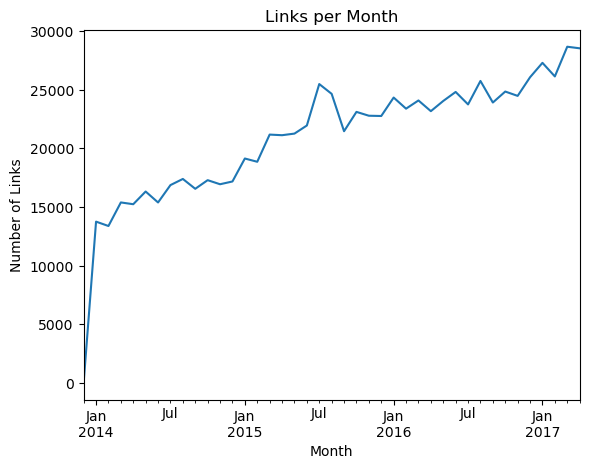

In [37]:
plot_links_per_month(df)

**Interpretation:**
The plot shows the number of inter-subreddit links per month from 2014 to 2017. After a sharp rise at the beginning of 2014, link activity steadily increases over time, reflecting growing cross-community interactions on Reddit. Between 2016 and 2017, the number of links continues to rise slightly, indicating that cross-subreddit activity was still expanding, though at a slower pace.


## 2.3 POINT BISERIAL ANALYSIS

=== Top 10 features most correlated with hostility (Point-Biserial) ===
         feature         r  p_value
42    LIWC_Swear -0.255260      0.0
50      LIWC_Anx -0.064933      0.0
60     LIWC_Incl -0.041926      0.0
27    LIWC_SheHe -0.080070      0.0
28     LIWC_They -0.069082      0.0
29    LIWC_Ipron -0.060692      0.0
30  LIWC_Article -0.052709      0.0
31    LIWC_Verbs -0.084356      0.0
32    LIWC_AuxVb -0.045339      0.0
66      LIWC_Bio -0.132735      0.0

=== 10 strongest negative correlations (more hostile features) ===
           feature         r  p_value
49     LIWC_Negemo -0.426115      0.0
51      LIWC_Anger -0.419349      0.0
19       VADER_neg -0.391294      0.0
47     LIWC_Affect -0.267396      0.0
42      LIWC_Swear -0.255260      0.0
69     LIWC_Sexual -0.136796      0.0
66        LIWC_Bio -0.132735      0.0
12  frac_stopwords -0.110394      0.0
21      LIWC_Funct -0.101752      0.0
2       frac_alpha -0.100182      0.0


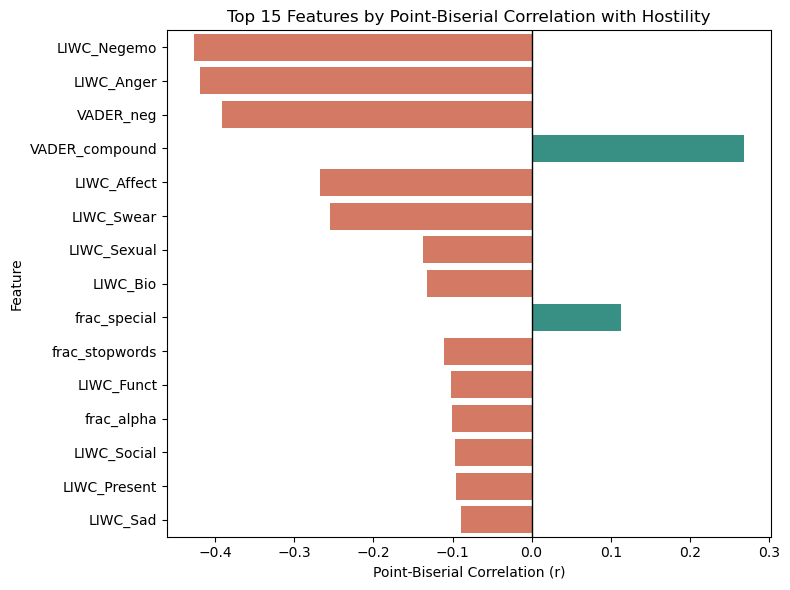

In [38]:
corr_df = point_biserial_analysis(df, property_names)

### **Interpretation**

The point-biserial correlation analysis reveals clear linguistic markers associated with hostility between subreddits. Features such as **LIWC_Negemo**, **LIWC_Anger**, **VADER_neg**, and **LIWC_Swear** show the strongest negative correlations with the sentiment label, indicating that messages containing more **negative emotions**, **anger-related words**, or **swearing** are more likely to be hostile. Conversely, features with small or positive correlations tend to appear more in non-hostile interactions.

While the *p-values* are numerically equal to zero due to the large sample size, this simply reflects that even small effects are statistically significant. The focus should therefore be on the **magnitude and direction** of the correlations rather than on their significance.

Overall, these results confirm that **affective and sentiment-based features capture meaningful differences in tone** between hostile and non-hostile links. The patterns align with intuitive linguistic behavior: hostile communication often involves **more emotional, negative, and aggressive language**.


## 2.4 LOGISTIC REGRESSION


=== Top 10 significant predictors ===
                   feature       coef        p_value
87                 is_body   0.960288   0.000000e+00
52              LIWC_Anger -10.529565   0.000000e+00
21          VADER_compound   0.724817   0.000000e+00
18       readability_index   0.555235   0.000000e+00
17  avg_words_per_sentence  -0.282667   0.000000e+00
11            avg_word_len  -2.771962   0.000000e+00
20               VADER_neg  -3.377263   0.000000e+00
5               frac_upper   6.669196   0.000000e+00
43              LIWC_Swear  -7.872325  7.651695e-193
44             LIWC_Social  -3.226544  4.245039e-178


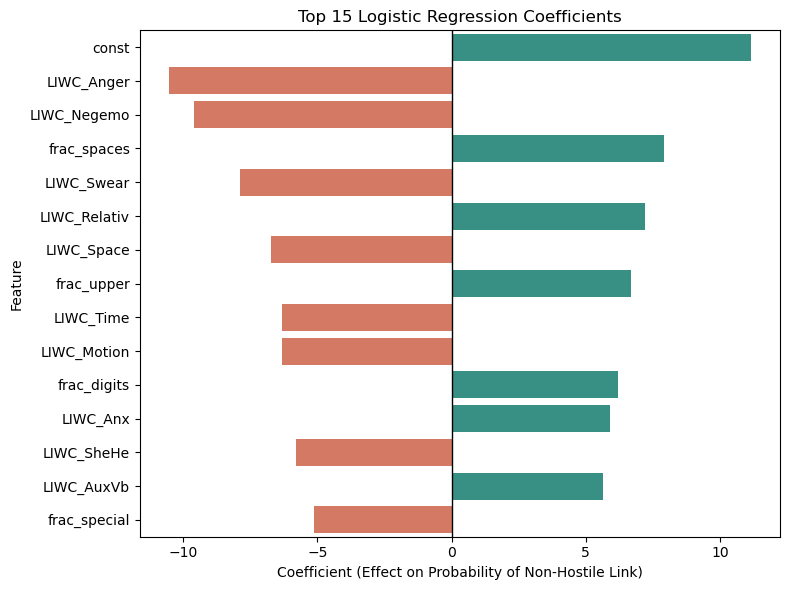

In [39]:
result, summary_df = logistic_regression(df, property_names)

### **Interpretation**

The logistic regression identifies several linguistic and structural predictors that distinguish hostile from non-hostile subreddit links. Negative coefficients such as **LIWC_Anger**, **LIWC_Swear**, and **VADER_neg** indicate that anger-related words, swearing, and higher negative sentiment strongly increase the likelihood of hostility. Conversely, positive coefficients such as **VADER_compound** and **readability_index** suggest that clearer and more positive messages are less hostile.

Interestingly, **is_body** has a positive effect, meaning that links from the post body are generally less hostile than those in titles, which tend to carry more emotionally charged or provocative wording.

All *p-values* appear as zero due to the very large sample size, making even small effects statistically significant. The interpretation should therefore focus on the **direction and strength of the coefficients**, not their p-values.

### **Comparison with the Correlation Analysis**

The logistic regression results are consistent with the point-biserial correlation findings. In both analyses, features related to **anger, negative emotion, and swearing** (e.g., *LIWC_Anger*, *LIWC_Negemo*, *VADER_neg*, *LIWC_Swear*) are the strongest indicators of hostility. Similarly, features capturing **positive tone or readability** (such as *VADER_compound* and *readability_index*) are associated with non-hostile links.

While the correlation analysis measured the relationship between each feature and hostility **individually**, the logistic regression accounts for the **combined and independent effect** of all predictors. The consistency between both methods reinforces the robustness of the observed linguistic patterns: **hostile subreddit interactions tend to be more emotional, negative, and impulsive**, whereas **non-hostile exchanges are generally more positive and structured**.


## 2.5 Correlation Matrix of Linguistic and Sentiment Properties

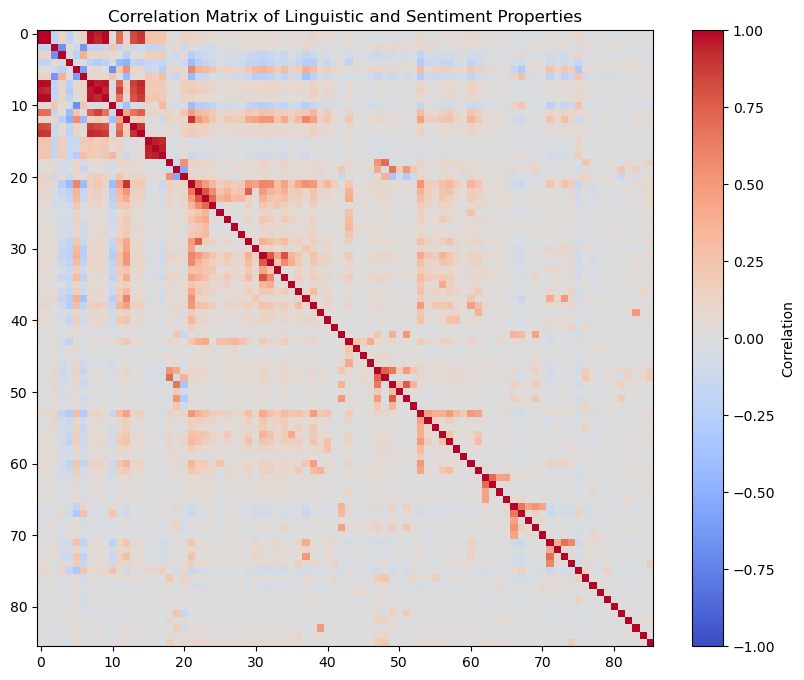

In [40]:
plot_feature_correlation(df, property_names)

### **Interpretation**

The correlation matrix above shows the pairwise relationships between all linguistic and sentiment features (e.g., LIWC, VADER, readability). Most correlations are close to zero (light gray), indicating that many features capture **distinct linguistic dimensions**. However, several **clusters of strong positive correlations** (in dark red) appear along the diagonal, suggesting that certain groups of features measure **similar psychological or lexical constructs**.

For example, LIWC categories related to **affect, anger, and negative emotion** are likely to be highly correlated, as they all reflect emotional tone. Similarly, structural metrics such as **word length**, **sentence length**, or **readability index** may also form small correlated clusters.

The limited number of strong off-diagonal correlations suggests that **most features contribute complementary information**, which is desirable for downstream modeling. However, a few highly correlated variables could still introduce **multicollinearity** in the logistic regression, potentially explaining minor convergence issues observed earlier.


## 2.6 Interesting Feature distribution 

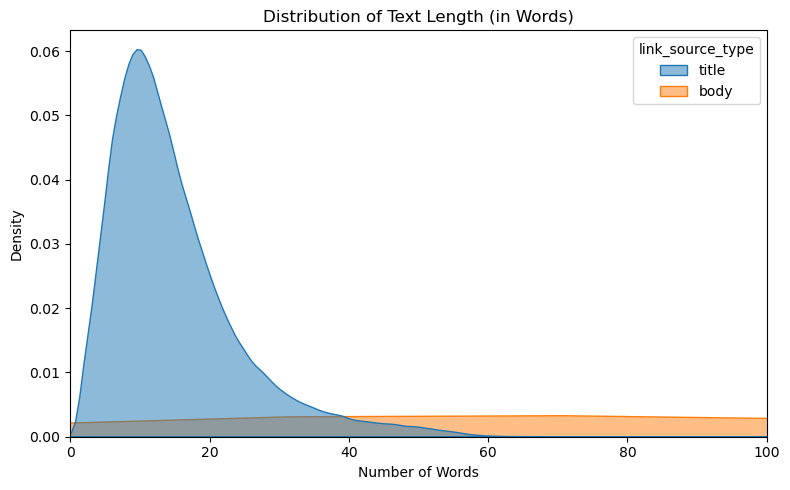

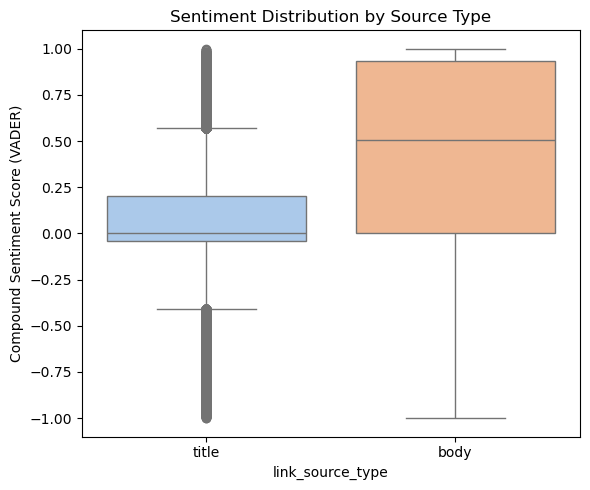

In [41]:
plot_feature_distributions(df)

### **Interpretation**

The first plot shows the **distribution of text length** (measured by the number of words) for links originating from **titles** and **bodies** of Reddit posts. Titles are generally much shorter, with a sharp peak around 10–15 words, reflecting their concise, attention-grabbing nature. In contrast, body links have a broader and flatter distribution, indicating longer, more elaborated content. This confirms that **titles and bodies serve different communicative roles** — titles summarize or provoke interest, while bodies provide richer context or explanations.

The second plot compares the **sentiment distribution (VADER compound score)** across the two source types. Body links exhibit a **higher and more positive median sentiment**, whereas titles are more centered around neutral or slightly negative values and show greater variability. This suggests that **titles tend to use stronger or more polarized language**, possibly to attract attention or express opinions, while **body texts are generally more positive or balanced**.

Together, these plots highlight consistent structural and emotional differences between titles and bodies, supporting the idea that **source type influences both length and sentiment of inter-subreddit links**.


## 2.7 Top subreddits

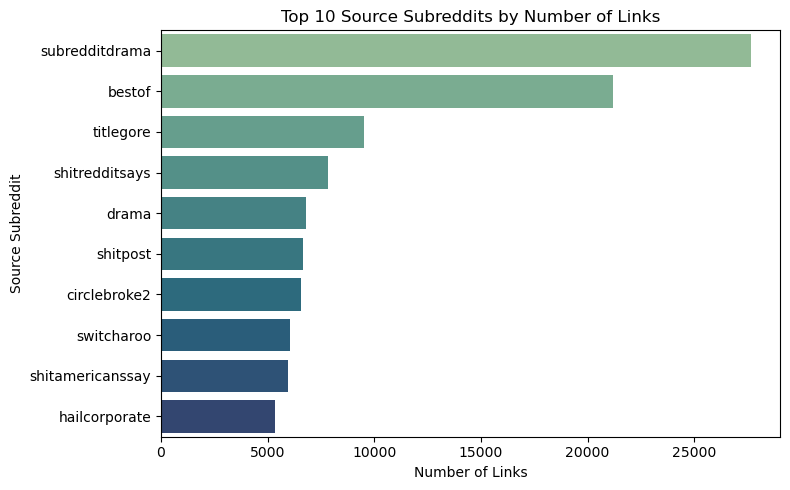

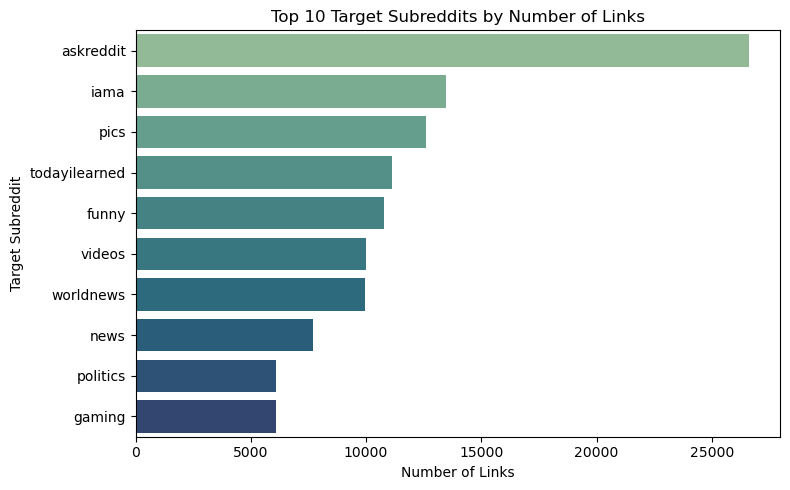

In [42]:
plot_top_subreddits(df)

### **Interpretation**

The first chart shows the top source subreddits by number of outgoing links. Communities such as **subredditdrama**, **bestof**, and **titlegore** appear as the main initiators of cross-subreddit interactions. These subreddits are typically focused on referencing or commenting on content from other communities, which explains their high number of outgoing links.

The second chart highlights the top target subreddits that receive the most links. Subreddits like **askreddit**, **iama**, and **pics** dominate as frequent destinations, reflecting their broad popularity and general-purpose nature. These communities tend to attract attention and discussion from across the platform.

Overall, the results reveal a structural asymmetry: some subreddits act as **sources of commentary and meta-discussion**, while others serve as **central hubs** that gather visibility and engagement from the wider Reddit network.


# PART 3 : NETWORK ANALYSIS OF INTER-SUBREDDIT LINKS


In this section, we model the interactions between subreddits as a **directed signed network**, where each node represents a subreddit and each edge corresponds to a hyperlink from one subreddit to another. The edge weight (`LINK_SENTIMENT`) encodes whether the interaction is **positive** or **negative**, allowing us to analyze both the structure and polarity of relationships across Reddit communities.

The function `build_graph()` constructs the directed graph from the dataset, while `compute_node_metrics()` computes key **node-level measures** such as degree, betweenness centrality, and PageRank, providing insights into the **influence and connectivity** of each subreddit. The `compute_global_balance_index()` function evaluates the **structural balance** of the network by examining triads (three-node subgraphs): a triad is considered balanced when the product of its edge signs equals +1. This helps quantify the overall **social harmony or tension** within the Reddit ecosystem.

Finally, `analyze_network()` orchestrates the full pipeline — from graph construction to metric computation — and returns a structured summary including the network object, node metrics, the **Global Balance Index**, and the **average node degree**. This analysis provides both **micro-level** (individual subreddit influence) and **macro-level** (network stability and balance) perspectives on inter-community interactions.


## 3.1 Construction of the network

In [47]:
from src.scripts.analysis_network import analyze_network

results = {}
results["network_analysis"] = analyze_network(df)


Directed signed graph built: 67,180 nodes, 339,643 edges
Computing node-level metrics...
Node metrics saved to reddit_node_metrics.csv
🔄 Computing Global Balance Index...


Checking triads: 100%|██████████| 67180/67180 [00:04<00:00, 14156.30it/s]

Global Balance Index: 0.742
Average node degree: 5.06


### **Average Degree**

The **average degree** of the subreddit interaction network is approximately **5.06**, meaning that each subreddit is connected to about five others on average (either linking to or being linked from them).
This indicates a **moderately connected structure**, where most communities interact with several others but are not densely interconnected.

A higher average degree would suggest strong cross-community engagement, while a lower value would point to a more **fragmented ecosystem** with isolated subreddits.
Thus, this value highlights a **balanced network**, where information and sentiment can circulate across multiple communities without forming a fully dense structure.

## 3.2 Global Results 

In [48]:
results["network_analysis"]

metrics_df = results["network_analysis"]["metrics"]


In [49]:
results["network_analysis"]["metrics"].head()

,subreddit,degree,in_degree,out_degree,degree_centrality,betweenness,pagerank
0,rddtgaming,3,0,3,0.000045,0.000000,0.000003
1,rddtrust,1,1,0,0.000015,0.000000,0.000004
2,xboxone,495,315,180,0.007368,0.001304,0.000783
3,battlefield_4,137,88,49,0.002039,0.000196,0.000184
4,ps4,522,324,198,0.007770,0.001010,0.000766


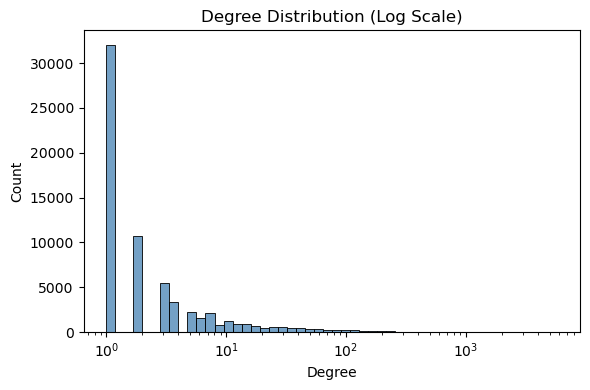

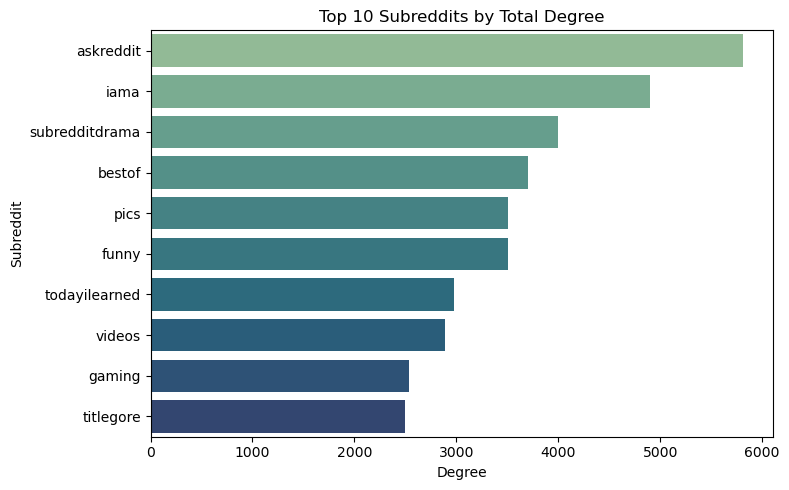

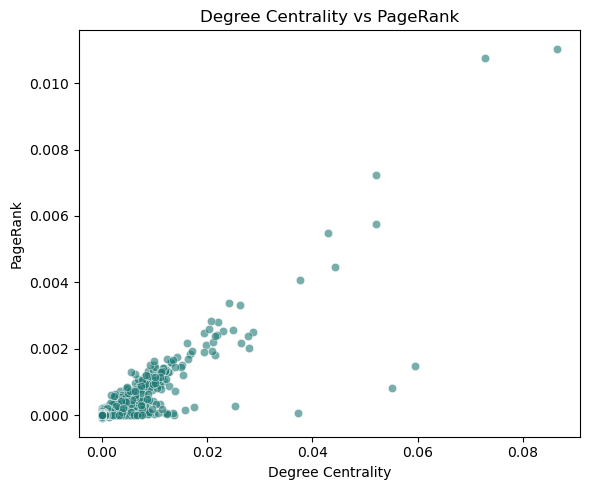

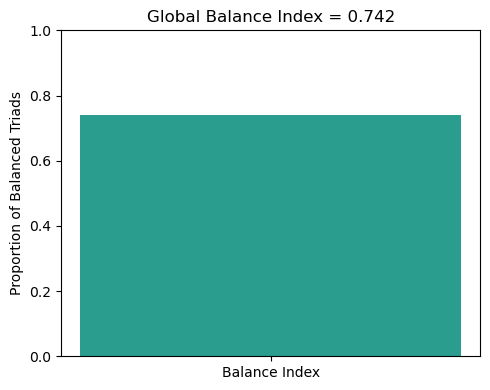

In [50]:
from src.scripts.analysis_network import plot_network_summary
# Generate all summary plots
plot_network_summary(results, original_df=df)


The degree distribution (log scale) shows a highly **right-skewed pattern**, indicating that most subreddits are weakly connected (low degree), while a few hubs maintain a very high number of connections. This structure is typical of **scale-free networks**, where a small number of nodes dominate the interaction flow.

The top-degree plot highlights those central hubs — such as **AskReddit**, **IAmA**, and **subredditdrama** — which serve as key intermediaries in the network, frequently linking to or being linked from many other communities.

The **Degree Centrality vs PageRank** scatterplot confirms this relationship: nodes with higher connectivity also tend to have higher influence, suggesting that **connectivity correlates with visibility and centrality** in inter-subreddit exchanges.

Finally, the **Global Balance Index (0.742)** indicates that roughly three-quarters of triadic relationships are **structurally balanced**, meaning the network tends toward coherent patterns of alliance and opposition rather than random hostility. Overall, the inter-subreddit network exhibits **strong hierarchical hubs and a relatively stable social structure**.


# PART 4 : MONTHLY ANALYSIS OF SENTIMENT LINKS

We will now conduct an analysis on a monthly basis accross all subreddit links. Working month by month turns the data into a time-indexed panel, so we can define clean pre/post windows around each co-attack and test whether A↔B friendship changes after the event without temporal leakage. This also helps to ensure that A and B attack C in the same period and reduce co-attacks that happen within long gaps.

## Positive and negative links observations

The following function, *build_monthly_counts()*, turns the raw post-level links into monthly summaries:
- pair_month: contains number of positive and negative links from a source to a target per month
- sub_month: contains number of positive and negative links from a source to any target per month.

In [51]:
pair_month, sub_month = build_monthly_counts(df_monthly)
pair_month.head(), sub_month.head()

(LINK_SENTIMENT    month     SOURCE_SUBREDDIT TARGET_SUBREDDIT  neg  pos
 0               2013-12            agitation     changemyview  0.0  1.0
 1               2013-12               bestof       confession  0.0  1.0
 2               2013-12        bitcoinmining          bitcoin  0.0  1.0
 3               2013-12               cancer       fuckcancer  0.0  1.0
 4               2013-12  circlejerkaustralia        australia  0.0  1.0,
 LINK_SENTIMENT    month            subreddit  out_pos  out_neg  out_total
 0               2013-12            agitation      1.0      0.0        1.0
 1               2013-12               bestof      1.0      0.0        1.0
 2               2013-12        bitcoinmining      1.0      0.0        1.0
 3               2013-12               cancer      1.0      0.0        1.0
 4               2013-12  circlejerkaustralia      1.0      0.0        1.0)

The following table illustrates the subreddits that attacked other targets more than 10 times.

In [52]:
sub_month[sub_month["out_neg"]>10]

LINK_SENTIMENT,month,subreddit,out_pos,out_neg,out_total
240,2014-01,askreddit,60.0,14.0,74.0
323,2014-01,badhistory,79.0,22.0,101.0
401,2014-01,bestof,465.0,94.0,559.0
681,2014-01,circlebroke,65.0,24.0,89.0
682,2014-01,circlebroke2,79.0,27.0,106.0
...,...,...,...,...,...
231262,2017-04,the_donald,141.0,27.0,168.0
231287,2017-04,thebluepill,30.0,19.0,49.0
231460,2017-04,topmindsofreddit,68.0,18.0,86.0
231906,2017-04,watchredditdie,9.0,13.0,22.0


Here we are visualizing the summary statistics of:
* Negative out-degree: for each subreddit and month, total # of negative links sent.
* Negative in-degree: for each subreddit and month, total # of negative links received.

This will help us avoid misreading later results and highlights where co-attacks and potential friendships can most likely be.

In [53]:
out_summ = negout_per_month_summary("neg_out", sub_month)
in_summ  = negin_per_month_summary("neg_in", pair_month)
print("Per-month out-degree summary:")
display(out_summ.head(10))
print("Per-month in-degree summary:")
display(in_summ.head(10))

Per-month out-degree summary:


,month,median,p25,p75,p90,p99,mean,count,min,max
0,2013-12,0.0,0.0,0.0,0.0,1.00,0.064516,31,0.0,1.0
1,2014-01,0.0,0.0,0.0,1.0,5.00,0.348257,3730,0.0,217.0
2,2014-02,0.0,0.0,0.0,1.0,6.00,0.343839,3871,0.0,269.0
3,2014-03,0.0,0.0,0.0,1.0,6.00,0.362928,4235,0.0,226.0
4,2014-04,0.0,0.0,0.0,1.0,5.00,0.358773,4337,0.0,256.0
5,2014-05,0.0,0.0,0.0,1.0,6.00,0.373788,4433,0.0,276.0
6,2014-06,0.0,0.0,0.0,1.0,5.37,0.354720,4364,0.0,265.0
7,2014-07,0.0,0.0,0.0,1.0,6.00,0.353744,4687,0.0,283.0
8,2014-08,0.0,0.0,0.0,1.0,6.00,0.352337,4771,0.0,237.0
9,2014-09,0.0,0.0,0.0,1.0,5.00,0.341568,4655,0.0,273.0


Per-month in-degree summary:


,month,median,p25,p75,p90,p99,mean,count,min,max
0,2013-12,0.0,0.0,0.0,0.0,1.00,0.064516,31,0.0,1.0
1,2014-01,0.0,0.0,0.0,1.0,7.00,0.477398,2721,0.0,74.0
2,2014-02,0.0,0.0,0.0,1.0,7.00,0.468662,2840,0.0,69.0
3,2014-03,0.0,0.0,0.0,1.0,7.40,0.502123,3061,0.0,106.0
4,2014-04,0.0,0.0,0.0,1.0,9.00,0.500322,3110,0.0,80.0
5,2014-05,0.0,0.0,0.0,1.0,9.00,0.510789,3244,0.0,80.0
6,2014-06,0.0,0.0,0.0,1.0,8.00,0.494253,3132,0.0,78.0
7,2014-07,0.0,0.0,0.0,1.0,7.68,0.482960,3433,0.0,91.0
8,2014-08,0.0,0.0,0.0,1.0,8.00,0.486541,3455,0.0,80.0
9,2014-09,0.0,0.0,0.0,1.0,8.00,0.471390,3373,0.0,72.0


#### Plot a

The following boxplot shows the distribution of negative_in and negative_out degrees per month.

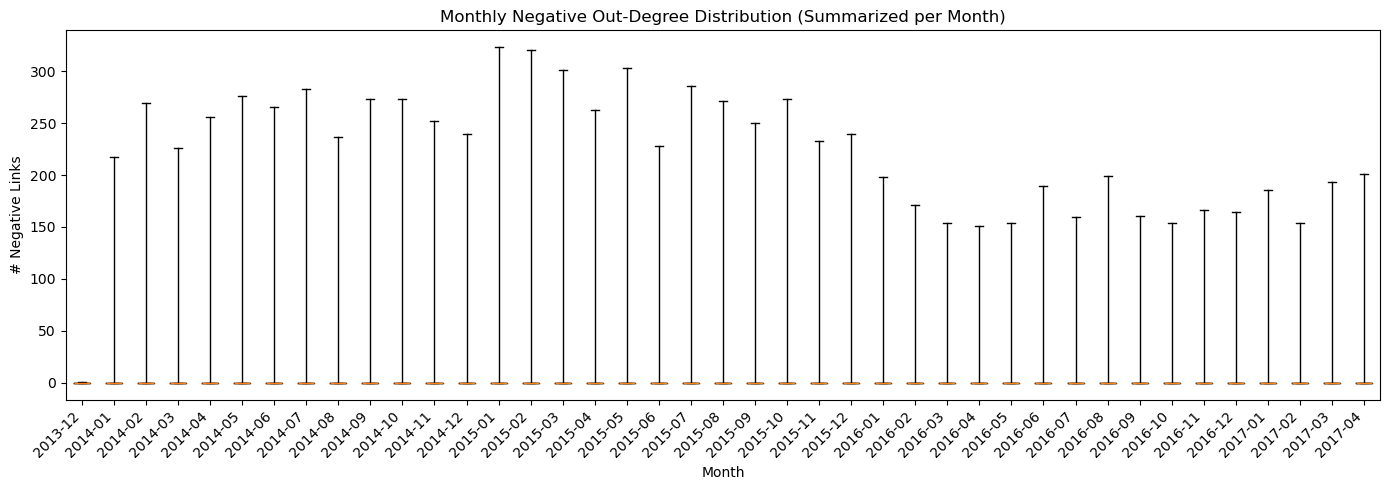

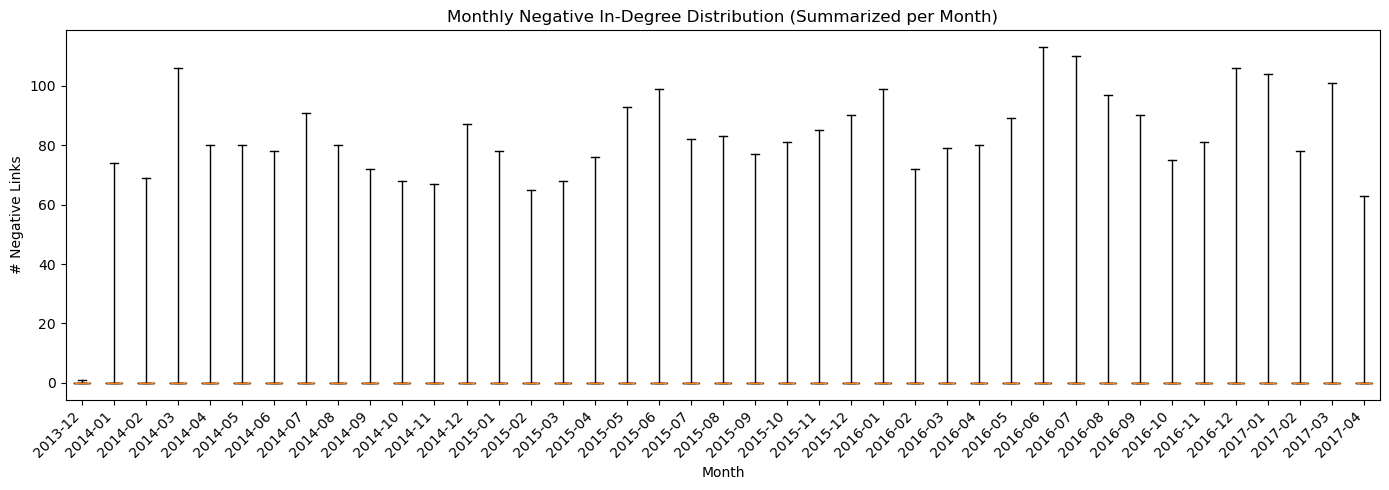

In [54]:
boxplot_from_summary(out_summ, "Monthly Negative Out-Degree Distribution (Summarized per Month)")
boxplot_from_summary(in_summ,  "Monthly Negative In-Degree Distribution (Summarized per Month)")

The boxplots reveal that negative interactions are rare overall but highly skewed — with a few subreddits responsible for most outgoing attacks and a few targets receiving most incoming ones.

#### Plot b

The following plot shows the percentage of targets, with respect to all other targets, that were co-attacked per month

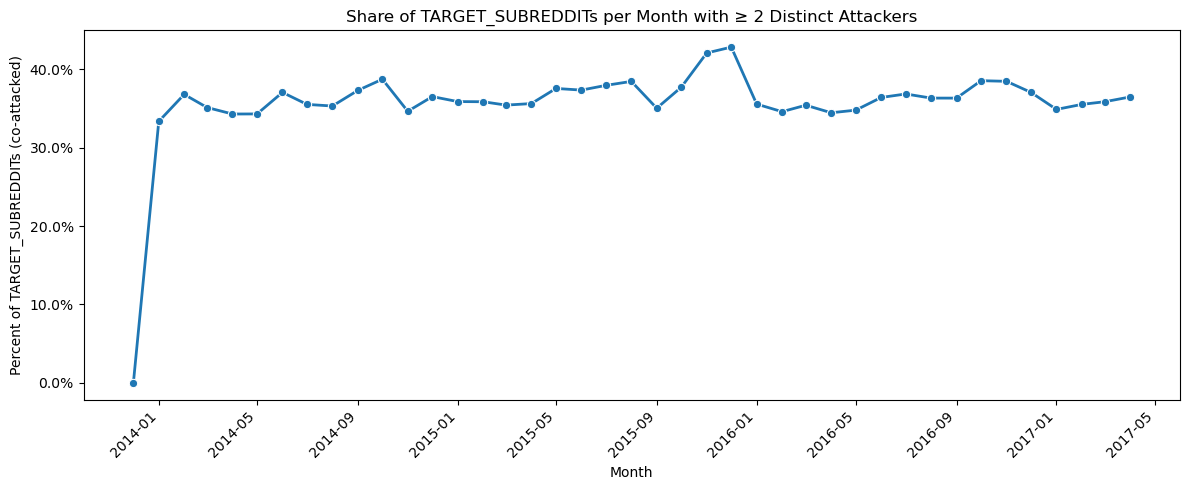

,month,n_TARGET_SUBREDDITs_total,n_TARGET_SUBREDDITs_multi,pct_multi,month_dt
0,2013-12,2,0,0.000000,2013-12-01
1,2014-01,498,166,0.333333,2014-01-01
2,2014-02,484,178,0.367769,2014-02-01
3,2014-03,527,185,0.351044,2014-03-01
4,2014-04,531,182,0.342750,2014-04-01
5,2014-05,595,204,0.342857,2014-05-01
6,2014-06,532,197,0.370301,2014-06-01
7,2014-07,569,202,0.355009,2014-07-01
8,2014-08,578,204,0.352941,2014-08-01
9,2014-09,574,214,0.372822,2014-09-01


In [55]:
summary = plot_pct_multi_attacked_TARGET_SUBREDDITs(pair_month, threshold=2)
summary.head(10)

A significant fraction of targets are attacked by multiple distinct communities every month, meaning that shared antagonism is a structural feature of Reddit dynamics.

## Target focused observations

Now that we have a better understanding of the data, we will examine the following: for each target subreddit C, record how much each attacker A negatively linked to C in each month, in a wide table. 

First, we mapped each unique month to an index ranging from 1 to 41 (we have 41 total unique months in the dataset) only for the purpose of a more compact view of the dataset. Next, in the following table, we built a table where each row is (C,A) and columns are months (1..41), with values equal the number of negative attacks from A to C in that month.

In [56]:
months_sorted, month_to_idx, idx_to_month = build_month_index_simple(pair_month)

Total months: 41
First few entries:
{'2013-12': 1, '2014-01': 2, '2014-02': 3, '2014-03': 4, '2014-04': 5, '2014-05': 6, '2014-06': 7, '2014-07': 8, '2014-08': 9, '2014-09': 10, '2014-10': 11, '2014-11': 12, '2014-12': 13, '2015-01': 14, '2015-02': 15, '2015-03': 16, '2015-04': 17, '2015-05': 18, '2015-06': 19, '2015-07': 20, '2015-08': 21, '2015-09': 22, '2015-10': 23, '2015-11': 24, '2015-12': 25, '2016-01': 26, '2016-02': 27, '2016-03': 28, '2016-04': 29, '2016-05': 30, '2016-06': 31, '2016-07': 32, '2016-08': 33, '2016-09': 34, '2016-10': 35, '2016-11': 36, '2016-12': 37, '2017-01': 38, '2017-02': 39, '2017-03': 40, '2017-04': 41}


In [57]:
target_attack_panel = build_target_attacks_panel(pair_month, months_sorted, month_to_idx)
print(target_attack_panel.shape)
display(target_attack_panel.head(10))

(41170, 43)


,C,A,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
0,nfl,subredditdrama,1,0,4,0,2,3,1,2,1,2,3,1,1,2,3,2,2,6,0,2,2,2,2,1,0,2,1,0,1,0,0,1,0,0,0,0,0,1,0,0,1
1,soccer,theredlion,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,askreddit,19thworldproblems,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,azcardinals,49ers,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,buffalobills,49ers,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,chargers,49ers,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,falcons,49ers,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,kansascitychiefs,49ers,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,nygiants,49ers,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,nyjets,49ers,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


For instance, in the first row, we notice that attacker A (subredditdrama) performed 1 attack on C (nfl) the first month, 4 attacks the third month, 2 attacks the fifth month, and so on.

In [58]:
high_activity = find_high_activity_pairs(target_attack_panel, n=8)

,C,A,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
1774,twoxchromosomes,shitredditsays,0,0,1,0,2,0,1,0,1,1,1,0,0,0,1,2,0,0,3,0,2,4,7,3,5,1,7,3,5,5,5,3,2,9,6,6,5,9,7,9,4


The number of attacker-TARGET_SUBREDDIT pairs (A → C) that ever had more than 8 negative posts in any single month is: 1


In [59]:
high_activity = find_high_activity_pairs(target_attack_panel, n=9)

,C,A,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41


The number of attacker-TARGET_SUBREDDIT pairs (A → C) that ever had more than 9 negative posts in any single month is: 0


For each attacker–target pair (A,C), we computed summary features: total, mean, max, min, standard deviation, and the number of months with at least one attack. It then keeps just these summaries plus A and C, and shows the first 100 rows

In [60]:
row_stats = compute_row_stats(target_attack_panel, month_prefix="month_", preview=100)

,C,A,sum_attacks,mean_attacks,max_attacks,min_attacks,std_attacks,months_active
0,nfl,subredditdrama,52,1.268293,6,0,1.304308,27
1,soccer,theredlion,1,0.024390,1,0,0.156174,1
2,askreddit,19thworldproblems,1,0.024390,1,0,0.156174,1
3,azcardinals,49ers,1,0.024390,1,0,0.156174,1
4,buffalobills,49ers,1,0.024390,1,0,0.156174,1
...,...,...,...,...,...,...,...,...
95,conservative,badhistory,2,0.048780,1,0,0.218085,2
96,conspiracy,badhistory,3,0.073171,1,0,0.263652,3
97,europe,badhistory,2,0.048780,1,0,0.218085,2
98,gifs,badhistory,1,0.024390,1,0,0.156174,1


Next, the following function counts the number of attacker-target pairs where the attacker made more than n attacks within m month.

In [61]:
run_snippet(row_stats, 1, 4)

,C,A,sum_attacks,mean_attacks,max_attacks,min_attacks,std_attacks,months_active
11884,windowsphone,wpbitchjerk,5,0.121951,5,0,0.780869,1
21460,subredditdramadrama,botsrights,6,0.146341,6,0,0.937043,1
25522,drama,boocisacuck,5,0.121951,5,0,0.780869,1


The number of attacker-target pairs where the source performed more than 4 attacks within 1 active month is: 3


## Study of pairs that co-attack a same target

After analyzing the negative links between A and C, this step builds a simple table that shows when two subreddits attacked the same target in the same month. For each target and each month, we keep the attackers with at least one attack; if there are two or more, we list every pair and record their two counts for that month. We then pivot this into one row per target–pair and columns for month_1…month_41, where each cell holds the two counts (or is empty if they didn’t both attack that month). We also sort the pair names to avoid duplicates and ensure all months are present. The result makes it easy to see when two communities co-attacked and how strong each one was.

The following result, for example at row 3, shows that A and B attacked C on month 37 with one attack each. 

In [62]:
pair_event_panel = build_pair_event_panel(target_attack_panel, months_sorted, month_to_idx)
display(pair_event_panel.head(10))
print(pair_event_panel.shape)

,C,A,B,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
0,1200isjerky,botrights,botsrights,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)"
1,1200isplenty,drama,proed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN
2,1200isplenty,fitnesscirclejerk,subredditdrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)"
3,2007scape,againstkarmawhores,bestof,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,NaN,NaN
4,2007scape,againstkarmawhores,justiceporn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,NaN,NaN
5,2007scape,againstkarmawhores,quityourbullshit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,NaN,NaN
6,2007scape,asablackman,circlebroke2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN
7,2007scape,bestof,circlebroke2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2007scape,bestof,drama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2007scape,bestof,justiceporn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,NaN,NaN


(270399, 44)


What we care about is trying to find strong co-attack pairs. We set a threshold x (3 in this case) and for each row (C, A, B), we scan the monthly cells (each is a tuple (countA, countB)). If both counts are strictly greater than X in any month, we mark that row as a strong pair. We then filter the table to only these strong pairs, show a sample, and print how many there are. This helps focus on meaningful, not accidental, overlaps in attacking activity.
For instance, in the fifth row, we observe that both A and B were strictly greater than x in month_5. Therefore,we selected that row.

In [63]:
x = 3
run_strong_attack_check(pair_event_panel, x)

,C,A,B,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
2071,adviceanimals,bestof,evenwithcontext,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 2)",NaN,NaN,NaN,"(1, 2)",NaN,"(4, 4)","(2, 2)",NaN,"(1, 2)","(2, 1)","(2, 2)",NaN,NaN,NaN,NaN,"(1, 1)","(1, 1)",NaN,NaN,NaN,"(4, 1)",NaN,NaN,NaN,NaN,"(1, 2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3141,adviceanimals,circlebroke,shitamericanssay,NaN,NaN,NaN,"(4, 4)",NaN,"(4, 2)","(1, 1)",NaN,"(4, 1)",NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)","(1, 1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8366,anarchism,drama,subredditdrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(4, 6)","(4, 4)","(4, 1)","(5, 3)","(7, 4)","(3, 3)","(4, 1)",NaN,"(3, 2)","(3, 1)","(4, 1)","(1, 2)",NaN,NaN,"(3, 1)",NaN,"(3, 1)","(2, 2)","(3, 1)","(3, 3)"
30181,askreddit,bestoftldr,subredditdrama,NaN,NaN,"(3, 3)","(3, 4)","(4, 4)",NaN,NaN,"(1, 4)","(4, 2)","(2, 1)","(3, 3)","(1, 1)","(5, 1)","(1, 5)",NaN,"(3, 4)","(4, 4)","(2, 3)","(2, 1)","(2, 1)",NaN,"(1, 2)","(1, 1)","(1, 2)","(1, 2)",NaN,"(2, 1)",NaN,"(2, 4)","(1, 5)","(1, 3)","(3, 1)","(4, 2)","(3, 2)","(1, 2)",NaN,"(3, 2)","(3, 2)","(1, 1)",NaN,NaN
30208,askreddit,bestoftldr,thathappened,NaN,"(3, 1)","(3, 1)","(3, 1)","(4, 4)",NaN,NaN,"(1, 3)","(4, 2)","(2, 1)","(3, 4)","(1, 1)",NaN,"(1, 2)",NaN,"(3, 2)","(4, 2)",NaN,"(2, 1)",NaN,NaN,NaN,"(1, 1)",NaN,"(1, 1)",NaN,NaN,NaN,"(2, 1)",NaN,NaN,NaN,NaN,"(3, 1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
30278,askreddit,bestoftldr,unexpectedhogwarts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1, 1)",NaN,"(4, 4)",NaN,NaN,NaN,NaN,"(3, 2)",NaN,NaN,NaN
36601,askreddit,circlebroke,evenwithcontext,NaN,"(5, 1)","(1, 4)","(2, 4)","(2, 1)","(3, 3)","(2, 3)","(2, 2)","(2, 1)",NaN,NaN,NaN,"(1, 1)","(2, 4)","(2, 2)",NaN,"(1, 3)","(2, 4)","(2, 2)",NaN,NaN,"(5, 4)",NaN,"(2, 2)","(2, 3)",NaN,"(1, 2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(2, 3)",NaN
37169,askreddit,circlebroke2,evenwithcontext,NaN,NaN,"(3, 4)","(4, 4)","(1, 1)","(2, 3)","(2, 3)","(1, 2)","(1, 1)","(1, 2)","(2, 3)","(1, 2)","(3, 1)","(1, 4)","(2, 2)",NaN,NaN,NaN,NaN,"(1, 2)","(2, 2)",NaN,"(2, 3)","(1, 2)","(3, 3)","(1, 3)","(1, 2)","(1, 4)",NaN,"(2, 2)","(4, 3)","(3, 1)",NaN,NaN,"(2, 5)","(2, 2)","(3, 1)","(2, 3)","(3, 4)","(1, 3)",NaN
37675,askreddit,circlebroke2,subredditdrama,NaN,NaN,"(3, 3)","(4, 4)","(1, 4)",NaN,"(2, 2)","(1, 4)","(1, 2)","(1, 1)","(2, 3)","(1, 1)","(3, 1)","(1, 5)","(2, 3)",NaN,NaN,NaN,NaN,"(1, 1)",NaN,NaN,"(2, 1)","(1, 2)","(3, 2)","(1, 3)","(1, 1)","(1, 1)","(1, 4)","(2, 5)","(4, 3)","(3, 1)","(2, 2)",NaN,"(2, 2)","(2, 2)","(3, 2)","(2, 2)","(3, 1)","(1, 4)",NaN
49217,askreddit,evenwithcontext,subredditdrama,NaN,NaN,"(4, 3)","(4, 4)","(1, 4)",NaN,"(3, 2)","(2, 4)","(1, 2)","(2, 1)","(3, 3)","(2, 1)","(1, 1)","(4, 5)","(2, 3)","(2, 4)","(3, 4)","(4, 3)","(2, 1)","(2, 1)",NaN,"(4, 2)","(3, 1)","(2, 2)","(3, 2)","(3, 3)","(2, 1)","(4, 1)",NaN,"(2, 5)","(3, 3)","(1, 1)",NaN,"(4, 2)","(5, 2)","(2, 2)","(1, 2)","(3, 2)","(4, 1)","(3, 4)",NaN


Total pairs (A,B) with >3 attacks each in any month: 49


For each (C, A, B) row, the code scans the month_* columns: the first month containing a co-attack tuple becomes start_month (1-based), and the total number of months with tuples becomes active_months. It then builds pair_summary with C, A, B and these two metrics (with start_month = NaN if there were no co-attacks).

In [64]:
pair_summary = build_pair_summary(pair_event_panel)
display(pair_summary.head(10))
print(pair_summary.shape)

,C,A,B,start_month,active_months
0,1200isjerky,botrights,botsrights,41,1
1,1200isplenty,drama,proed,39,1
2,1200isplenty,fitnesscirclejerk,subredditdrama,41,1
3,2007scape,againstkarmawhores,bestof,37,1
4,2007scape,againstkarmawhores,justiceporn,37,1
5,2007scape,againstkarmawhores,quityourbullshit,37,1
6,2007scape,asablackman,circlebroke2,39,1
7,2007scape,bestof,circlebroke2,30,1
8,2007scape,bestof,drama,25,1
9,2007scape,bestof,justiceporn,37,1


(270399, 5)


In [65]:
run_active_months_check(pair_summary,10)

,C,A,B,start_month,active_months
551,adviceanimals,againstkarmawhores,subredditdrama,21,12
2040,adviceanimals,bestof,circlebroke,2,15
2041,adviceanimals,bestof,circlebroke2,2,23
2071,adviceanimals,bestof,evenwithcontext,7,11
2081,adviceanimals,bestof,fitnesscirclejerk,2,12
...,...,...,...,...,...
268249,wtf,evenwithcontext,shitredditsays,6,14
268257,wtf,evenwithcontext,subredditdrama,7,17
269902,wtf,shitpost,shitredditsays,3,12
269914,wtf,shitpost,subredditdrama,3,13


The number of pairs (A,B)-C where co-attackers were active at the same time for more than 10 months is: 749


In [66]:
pair_summary.describe(percentiles=[.25,.5,.75,.9,.95])

,start_month,active_months
count,270399.000000,270399.000000
mean,22.490390,1.281835
std,11.354147,1.117313
min,2.000000,1.000000
25%,13.000000,1.000000
50%,23.000000,1.000000
75%,32.000000,1.000000
90%,38.000000,2.000000
95%,40.000000,3.000000
max,41.000000,34.000000


### Friendship between co-attacking pairs

After studying the attacks on a traget C, we need to check whether the attacking pairs become friends after a while. To do so, we make a simple table for every pair of subreddits that ever attacked the same target together. For each month, we write how many positive links went from A→B and B→A using the following format (X,Y) where X represents the number of positive links from A→B and Y from B→A. We insert NaN if both X and Y are 0. This lets us easily compare before vs after the joint attack to see if they got friendlier, and it’s ready for quick plots or simple stats.

In [67]:
friendship_panel = build_pair_friendship_panel(pair_event_panel, pair_month, months_sorted, month_to_idx)
display(friendship_panel.head(10))
print(friendship_panel.shape)

,A,B,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
0,10cloverfieldlane,circlebroke2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10cloverfieldlane,danlebatardshow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10cloverfieldlane,drama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10cloverfieldlane,negareddit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10cloverfieldlane,redlettermedia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10cloverfieldlane,subredditdrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10cloverfieldlane,topmindsofreddit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1200isjerky,exjw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1200isjerky,help_with_math,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1200isjerky,negareddit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(180125, 43)


We then visualize the pairs that exhibited at least one positive link either from A to B or B to A.

In [68]:
get_active_pairs(friendship_panel)

,A,B,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
62,18bfriendzonest,dota2,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,18bfriendzonest,subredditdrama,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138,18bfriendzonest,trueredditdrama,NaN,NaN,NaN,NaN,"(0, 1.0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163,195,atheism,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
187,195,casualconversation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
197,195,commentgore,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0, 1.0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
254,195,lewronggeneration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0, 1.0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,195,mildlyinfuriating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
302,195,shitstatistssay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0, 1.0)",NaN,NaN,NaN
306,195,showerthoughts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of active (A,B) pairs with at least one positive link: 23396


,A,B,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
62,18bfriendzonest,dota2,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,18bfriendzonest,subredditdrama,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138,18bfriendzonest,trueredditdrama,NaN,NaN,NaN,NaN,"(0, 1.0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
163,195,atheism,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
187,195,casualconversation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180084,writing,writingprompts,NaN,"(2.0, 2.0)",NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(1.0, 1.0)","(1.0, 0)","(1.0, 0)","(0, 1.0)","(1.0, 1.0)",NaN,"(3.0, 0)",NaN,NaN,NaN,NaN,"(1.0, 1.0)","(1.0, 1.0)","(0, 1.0)",NaN,NaN,"(0, 1.0)",NaN,NaN,NaN,"(1.0, 0)",NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN
180087,writingprompt,writingprompts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0, 1.0)","(0, 1.0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
180090,writingprompts,wtf,NaN,NaN,"(1.0, 0)",NaN,NaN,NaN,NaN,"(3.0, 0)","(1.0, 0)","(1.0, 0)",NaN,"(2.0, 0)","(2.0, 0)","(1.0, 0)","(1.0, 0)",NaN,NaN,NaN,NaN,"(1.0, 0)","(1.0, 0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
180091,writingprompts,wtfdidijustread,NaN,"(0, 1.0)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0, 1.0)",NaN


We summarize the friendship timeline for each pair (A, B): we scan the month_* cells and set start_month to the first month that has at least one positive link A→B or B→A, and active_months to the total number of months with any positive link. The resulting friendship_stat table lists each pair with these two metrics so we can see when their positive interaction starts and how persistent it is (note: start_month = 0 means no positive links at all).

In [69]:
friendship_stat = build_friendship_stat(friendship_panel)

,A,B,start_month,active_months
0,10cloverfieldlane,circlebroke2,0,0
1,10cloverfieldlane,danlebatardshow,0,0
2,10cloverfieldlane,drama,0,0
3,10cloverfieldlane,negareddit,0,0
4,10cloverfieldlane,redlettermedia,0,0
5,10cloverfieldlane,subredditdrama,0,0
6,10cloverfieldlane,topmindsofreddit,0,0
7,1200isjerky,exjw,0,0
8,1200isjerky,help_with_math,0,0
9,1200isjerky,negareddit,0,0


(180125, 4)


In [70]:
friendship_stat[friendship_stat["start_month"]>0]

,A,B,start_month,active_months
62,18bfriendzonest,dota2,7,1
127,18bfriendzonest,subredditdrama,7,1
138,18bfriendzonest,trueredditdrama,5,1
163,195,atheism,2,1
187,195,casualconversation,14,1
...,...,...,...,...
180084,writing,writingprompts,2,14
180087,writingprompt,writingprompts,19,2
180090,writingprompts,wtf,3,10
180091,writingprompts,wtfdidijustread,2,2


## Summary of co-attackers' relationship evolution

This step lines up each co-attacking trio (C,A,B) on a common timeline and asks a simple question: did A and B show positive links after they started co-attacking C? We take the first co-attack month as “time-zero” (conflict_start), total all positives A→B and B→A before and after that point (pre_sum, post_sum), and define the change friendship_evolution = post_sum − pre_sum. We also record when friendship first appeared (friendship_start), whether any friendship was observed, and whether it was new (no positives before, some after).

In [71]:
comparison = build_conflict_friendship_comparison(
    pair_event_panel=pair_event_panel,
    pair_summary=pair_summary,             # from co-attack summary (per C,A,B)
    friendship_panel=friendship_panel,     # per (A,B) monthly (x,y)
    friendship_stat=friendship_stat,       # per (A,B) start_month + active_months
    months_sorted=months_sorted
)

display(comparison.head(15))
print(comparison.shape)


,C,A,B,conflict_start,friendship_start,friendship_observed,pre_sum,post_sum,friendship_evolution,new_friendship
0,1200isjerky,botrights,botsrights,41,0,False,0,0,0,False
1,1200isplenty,drama,proed,39,0,False,0,0,0,False
2,1200isplenty,fitnesscirclejerk,subredditdrama,41,2,True,30,1,-29,False
3,2007scape,againstkarmawhores,bestof,37,0,False,0,0,0,False
4,2007scape,againstkarmawhores,justiceporn,37,0,False,0,0,0,False
5,2007scape,againstkarmawhores,quityourbullshit,37,18,True,2,1,-1,False
6,2007scape,asablackman,circlebroke2,39,0,False,0,0,0,False
7,2007scape,bestof,circlebroke2,30,5,True,27,7,-20,False
8,2007scape,bestof,drama,25,13,True,2,10,8,False
9,2007scape,bestof,justiceporn,37,3,True,21,1,-20,False


(270399, 10)


In [72]:
comparison[comparison['new_friendship']==True]

,C,A,B,conflict_start,friendship_start,friendship_observed,pre_sum,post_sum,friendship_evolution,new_friendship
13,2007scape,drama,shitamericanssay,25,28,True,0,6,6,True
24,2007scape,peoplewhosayheck,subredditdrama,41,41,True,0,1,1,True
33,3ds,openbroke,shitredditsays,6,40,True,0,1,1,True
37,49ers,chibears,panthers,2,12,True,0,13,13,True
46,4chan,againsthatesubreddits,shitstatistssay,32,41,True,0,1,1,True
...,...,...,...,...,...,...,...,...,...,...
270333,xkcd,drama,openbroke,3,18,True,0,1,1,True
270353,youshouldknow,evenwithcontext,subredditdrama,8,14,True,0,3,3,True
270360,youtubehaiku,badlegaladvice,shitredditsays,14,21,True,0,1,1,True
270363,youtubehaiku,badphilosophy,shitpost,19,29,True,0,1,1,True


In [73]:
comparison[(comparison['friendship_evolution'] < 0) & (comparison['friendship_observed'] == True)]
print(f"Fraction of co-attacking pairs that were already friends before the conflict and had a negative friendship evolution: "
      f"{((comparison['friendship_evolution'] < 0) & (comparison['friendship_observed'] == True)).mean() * 100:.3f}%")

Fraction of co-attacking pairs that were already friends before the conflict and had a negative friendship evolution: 9.312%


In [74]:
new_frac = comparison["new_friendship"].mean()
print(f"Fraction of co-attacking pairs that became new friends: {new_frac*100:.3f}%")
not_observed_frac = (comparison["friendship_observed"] == False).mean()
print(f"Fraction of co-attacking pairs that were not friends and did NOT become friends: {not_observed_frac*100:.3f}%")
old_friends_frac = (
    ((comparison["friendship_observed"] == True) & 
     (comparison["new_friendship"] == False))
).mean()

print(f"Fraction of co-attacking pairs that were friends before and stayed friends: {old_friends_frac*100:.3f}%")

Fraction of co-attacking pairs that became new friends: 9.233%
Fraction of co-attacking pairs that were not friends and did NOT become friends: 74.265%
Fraction of co-attacking pairs that were friends before and stayed friends: 16.502%


#### Plot c

Pie Chart illustrating the different computed fractions previously discussed.

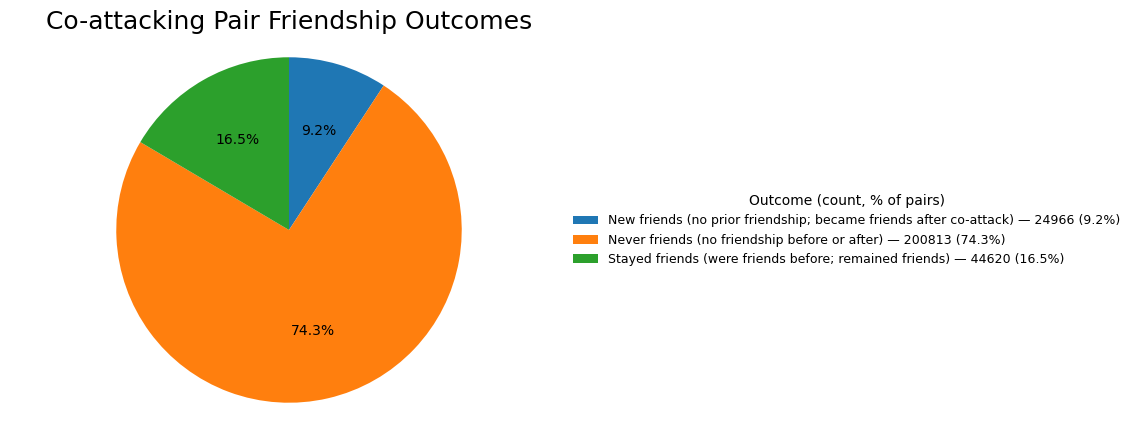

In [75]:
plot_friendship_outcomes_pie(comparison)

### Plot d

This plot shows the timeline of friendship formation for subreddit pairs (A, B) that jointly attacked the same target (C) and later became friends.

Each horizontal line corresponds to one pair of attackers.

The red dot marks the month they first co-attacked the target (the conflict event).

The green dot marks the month when they first showed a positive connection toward each other (friendship formation).

The distance between the dots represents the time it took for their relationship to turn positive — the lag from conflict to friendship.

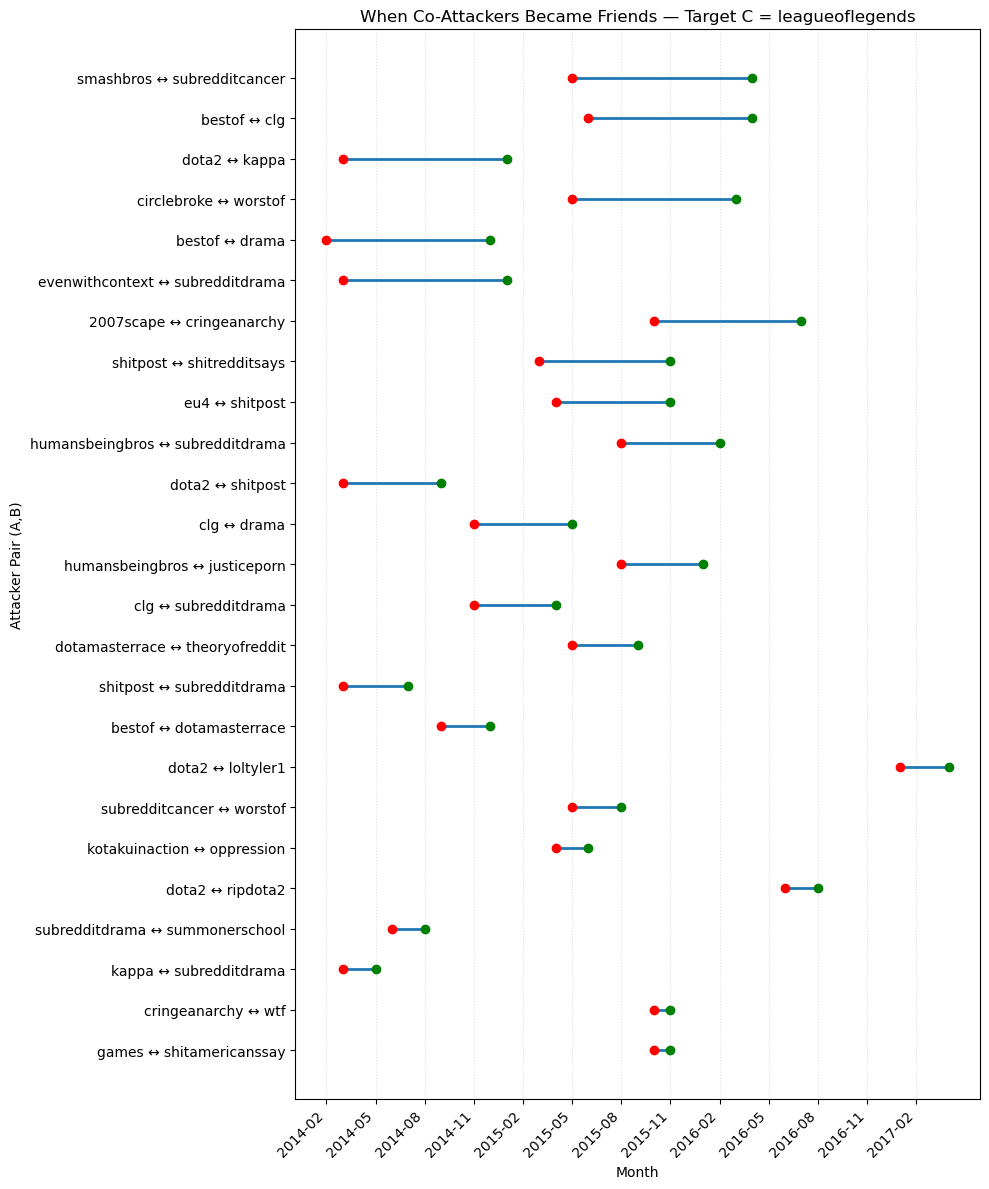

,A,B,C,conflict_month,friendship_month,delta
135691,games,shitamericanssay,leagueoflegends,2015-10,2015-11,1
135519,cringeanarchy,wtf,leagueoflegends,2015-10,2015-11,1
135759,kappa,subredditdrama,leagueoflegends,2014-03,2014-05,2
135927,subredditdrama,summonerschool,leagueoflegends,2014-06,2014-08,2
135549,dota2,ripdota2,leagueoflegends,2016-06,2016-08,2
135773,kotakuinaction,oppression,leagueoflegends,2015-04,2015-06,2
135926,subredditcancer,worstof,leagueoflegends,2015-05,2015-08,3
135544,dota2,loltyler1,leagueoflegends,2017-01,2017-04,3
135312,bestof,dotamasterrace,leagueoflegends,2014-09,2014-12,3
135907,shitpost,subredditdrama,leagueoflegends,2014-03,2014-07,4


In [76]:
_ = plot_new_friendship_timelines(comparison, idx_to_month, C_SEL="leagueoflegends", TOPN=25)

The timeline shows that many subreddit pairs who co-attacked the same target later became friends, but often after a delay.
This suggests that shared conflict can precede alliance, yet the timing and frequency vary widely.

Such variability raises a key question: is friendship formation truly driven by the co-attack itself, or by other factors such as pre-existing similarities between subreddits?
To answer this, the next part of the analysis will focus on isolating the causal effect of co-attacks on friendship formation while controlling for confounding factors like subreddits similarity, activity level (log of total outgoing links), and aggressiveness (ratio of negative to total outgoing links) (In milestone P3)


## Part 5: Using a new definition for friendship observation

In the initial phase, we defined *friendship* between two subreddits (A, B) as the first occurrence of a positive (+1) link in either direction. While this captures signs of endorsement of approval, it does not necessarily indicate a genuine, mutual relationship.

To obtain a more accurate representation of inter-community ties, we refined this definition to require *reciprocity*: both subreddits must have exchanged at least one positive link. In this framework, friendship is established only when positivity flows in both directions, signaling mutual acknowledgment rather than isolated interaction.



In [77]:
friendship_panel_strict = build_pair_friendship_panel_strict(pair_event_panel, pair_month, months_sorted, month_to_idx)
display(friendship_panel_strict.head(10))
print(friendship_panel_strict.shape)

,A,B,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,month_13,month_14,month_15,month_16,month_17,month_18,month_19,month_20,month_21,month_22,month_23,month_24,month_25,month_26,month_27,month_28,month_29,month_30,month_31,month_32,month_33,month_34,month_35,month_36,month_37,month_38,month_39,month_40,month_41
0,10cloverfieldlane,circlebroke2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10cloverfieldlane,danlebatardshow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10cloverfieldlane,drama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10cloverfieldlane,negareddit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10cloverfieldlane,redlettermedia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10cloverfieldlane,subredditdrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10cloverfieldlane,topmindsofreddit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1200isjerky,exjw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1200isjerky,help_with_math,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1200isjerky,negareddit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(180125, 43)


In [78]:
friendship_stat_strict = build_friendship_stat(friendship_panel_strict)

,A,B,start_month,active_months
0,10cloverfieldlane,circlebroke2,0,0
1,10cloverfieldlane,danlebatardshow,0,0
2,10cloverfieldlane,drama,0,0
3,10cloverfieldlane,negareddit,0,0
4,10cloverfieldlane,redlettermedia,0,0
5,10cloverfieldlane,subredditdrama,0,0
6,10cloverfieldlane,topmindsofreddit,0,0
7,1200isjerky,exjw,0,0
8,1200isjerky,help_with_math,0,0
9,1200isjerky,negareddit,0,0


(180125, 4)


In [79]:
comparison_strict = build_conflict_friendship_comparison(
    pair_event_panel=pair_event_panel,
    pair_summary=pair_summary,             # from co-attack summary (per C,A,B)
    friendship_panel=friendship_panel_strict,     # per (A,B) monthly (x,y)
    friendship_stat=friendship_stat_strict,       # per (A,B) start_month + active_months
    months_sorted=months_sorted
)

display(comparison_strict.head(15))
print(comparison_strict.shape)


,C,A,B,conflict_start,friendship_start,friendship_observed,pre_sum,post_sum,friendship_evolution,new_friendship
0,1200isjerky,botrights,botsrights,41,0,False,0,0,0,False
1,1200isplenty,drama,proed,39,0,False,0,0,0,False
2,1200isplenty,fitnesscirclejerk,subredditdrama,41,34,True,2,0,-2,False
3,2007scape,againstkarmawhores,bestof,37,0,False,0,0,0,False
4,2007scape,againstkarmawhores,justiceporn,37,0,False,0,0,0,False
5,2007scape,againstkarmawhores,quityourbullshit,37,0,False,0,0,0,False
6,2007scape,asablackman,circlebroke2,39,0,False,0,0,0,False
7,2007scape,bestof,circlebroke2,30,0,False,0,0,0,False
8,2007scape,bestof,drama,25,25,True,0,4,4,True
9,2007scape,bestof,justiceporn,37,17,True,2,0,-2,False


(270399, 10)


In [80]:
new_frac_strict = comparison_strict["new_friendship"].mean()
print(f"Fraction of co-attacking pairs that became new friends: {new_frac_strict*100:.3f}%")
not_observed_frac_strict = (comparison_strict["friendship_observed"] == False).mean()
print(f"Fraction of co-attacking pairs that were not friends and did NOT become friends: {not_observed_frac_strict*100:.3f}%")
old_friends_frac_strict = (
    ((comparison_strict["friendship_observed"] == True) & 
     (comparison_strict["new_friendship"] == False))
).mean()

print(f"Fraction of co-attacking pairs that were friends before and stayed friends: {old_friends_frac_strict*100:.3f}%")

Fraction of co-attacking pairs that became new friends: 1.975%
Fraction of co-attacking pairs that were not friends and did NOT become friends: 95.288%
Fraction of co-attacking pairs that were friends before and stayed friends: 2.737%


#### Plot e

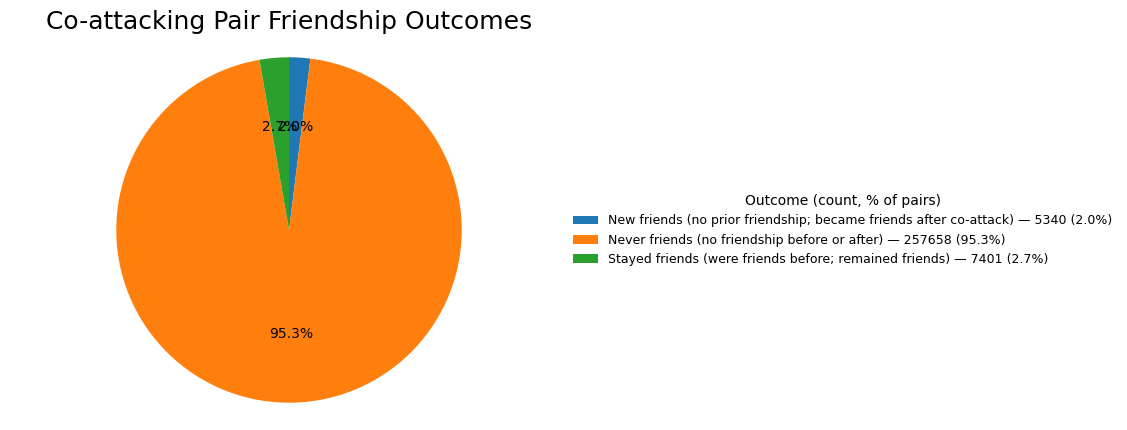

In [81]:
plot_friendship_outcomes_pie(comparison_strict)

#### Plot f

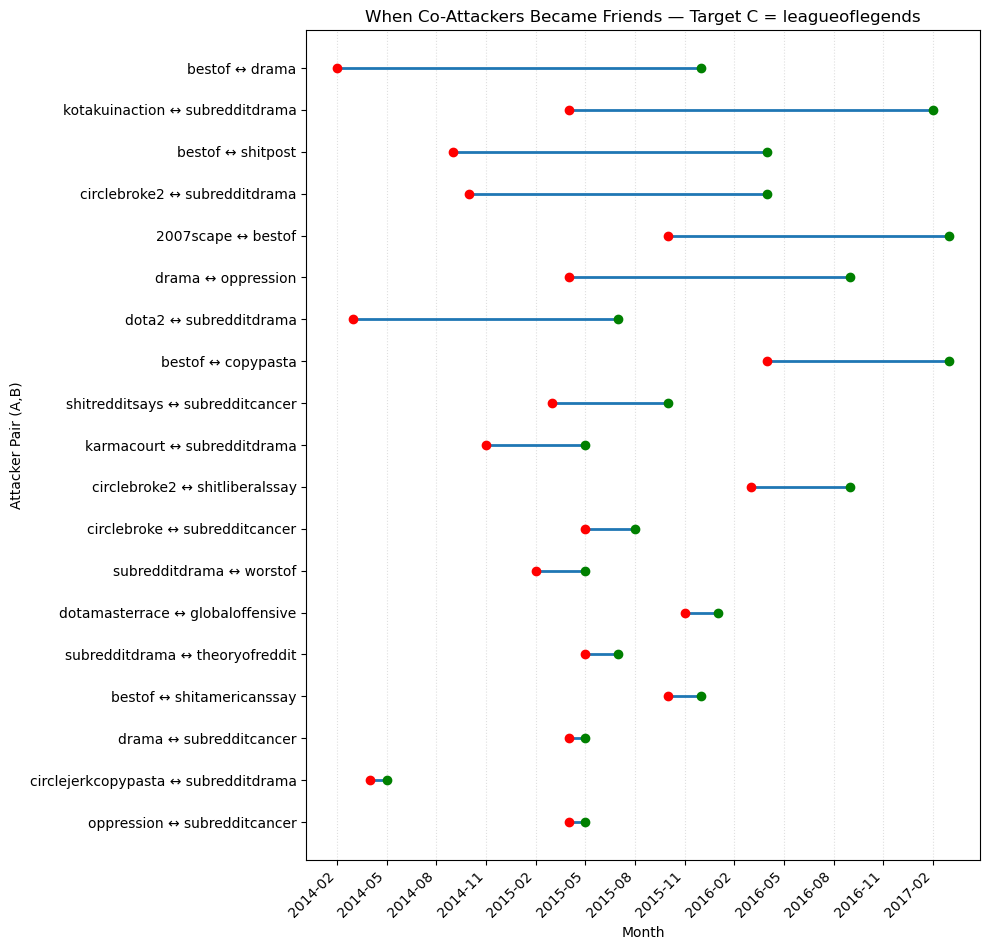

,A,B,C,conflict_month,friendship_month,delta
135857,oppression,subredditcancer,leagueoflegends,2015-04,2015-05,1
135423,circlejerkcopypasta,subredditdrama,leagueoflegends,2014-04,2014-05,1
135625,drama,subredditcancer,leagueoflegends,2015-04,2015-05,1
135328,bestof,shitamericanssay,leagueoflegends,2015-10,2015-12,2
135935,subredditdrama,theoryofreddit,leagueoflegends,2015-05,2015-07,2
135566,dotamasterrace,globaloffensive,leagueoflegends,2015-11,2016-01,2
135945,subredditdrama,worstof,leagueoflegends,2015-02,2015-05,3
135397,circlebroke,subredditcancer,leagueoflegends,2015-05,2015-08,3
135411,circlebroke2,shitliberalssay,leagueoflegends,2016-03,2016-09,6
135761,karmacourt,subredditdrama,leagueoflegends,2014-11,2015-05,6


In [82]:
_ = plot_new_friendship_timelines(comparison_strict, idx_to_month, C_SEL="leagueoflegends", TOPN=25)

Applying this stricter definition naturally reduced the number of pairs classified as “new friendships.” This means that many of the earlier “friendships” were asymmetric - one subreddit expressed support or positivity toward another, but the feeling wasn’t mutual.

Overall, the fraction of co-attacking pairs that were not friends and did not become friends after the conflict increased at the expense of the decrease of the other two fractions, indicative of the new definition’s more conservative idea of friendship.

This refinement of the friendship definition strengthens the analysis by providing a more conservative and realistic measure of alliance formation, and by improving the causal interpretability of the results by ensuring that the friendships we observe are closer to genuine social alignment rather than incidental positive mentions. 

Note that the percentages we observed are highly affected by the time window choice.
Therefore, our next steps will consist in evaluating how the time window affects our results, aiming at picking an optimal one. Furthermore, as mentioned in the motivation at the end of plot d, we will be analyzing the effect of other possible confounders to truly evaluate whether co-attacking a common target is the cause of later observed friendship


# PART 6 : MAP VISUALIZATION WITH TEMPORAL EVOLUTION

To better understand how interactions between communities evolve over time, we built an **interactive temporal network visualization** using **Plotly**.

Each **node** in the network represents a subreddit, positioned in a 2D embedding space obtained via **UMAP dimensionality reduction** applied to the original high-dimensional subreddit embeddings.
Each **directed edge** corresponds to an inter-subreddit link, colored by sentiment:

* **Blue edges** represent **positive or cooperative** interactions.
* **Red edges** represent **hostile or conflictual** interactions.

### **Methodology**

1. **Embedding projection:**
   Subreddit embeddings were reduced to two dimensions with UMAP for clear spatial visualization.
2. **Temporal aggregation:**
   Interactions were grouped by month based on their timestamps, allowing us to analyze monthly trends.
3. **Frame construction:**
   For each month, the number of links between subreddit pairs was aggregated and visualized as weighted edges, where edge thickness reflects interaction frequency.
4. **Animation assembly:**
   Using Plotly, we combined these monthly frames into a smooth animation showing the **evolution of emotional flows** over time.

### **Interpretation**

This animation provides an intuitive view of how subreddit relationships evolve:

* The **appearance or disappearance of edges** indicates shifting communication patterns.
* The **balance between red and blue links** reveals changes in overall sentiment across the platform.
* Dense clusters of edges highlight communities that are highly interconnected, either through cooperation or conflict.

### **Outcome**

This temporal visualization allows us to:

* Observe **how hostility and cooperation propagate** across Reddit communities.
* Identify **key subreddits** acting as hubs of interaction.
* Detect **periods of increased tension or alignment** between communities.

Overall, this approach bridges **linguistic sentiment analysis** and **network dynamics**, offering a comprehensive view of online inter-community behavior over time.


***important notes!!***

**- Please make sure to download the required dependencies mentionned in pip_requirements to be able to visualize the map.**

**- Due to github size restrictions, we cannot upload a notebook with size larger than 25 mb. Therefore, we had to ommit the interactive map output from the submission. However, we invite you to run the following code on your device to try the interactive map. Nevertheless, we are inserting two screenshots of the map at 2 different time instances so that you can still see what it looks like if you don't want to run the code. Thanks for understanding!**

In [ ]:
from src.scripts.visualize_network import animate_network
from src.scripts.visualize_network import process_embeddings  # your new function

# Preprocess embeddings first
emb_df, emb_map = process_embeddings(emb_df)

# Then animate using the processed embeddings
fig = animate_network(df, emb_df)
fig.show()




**Screenshot 1:**

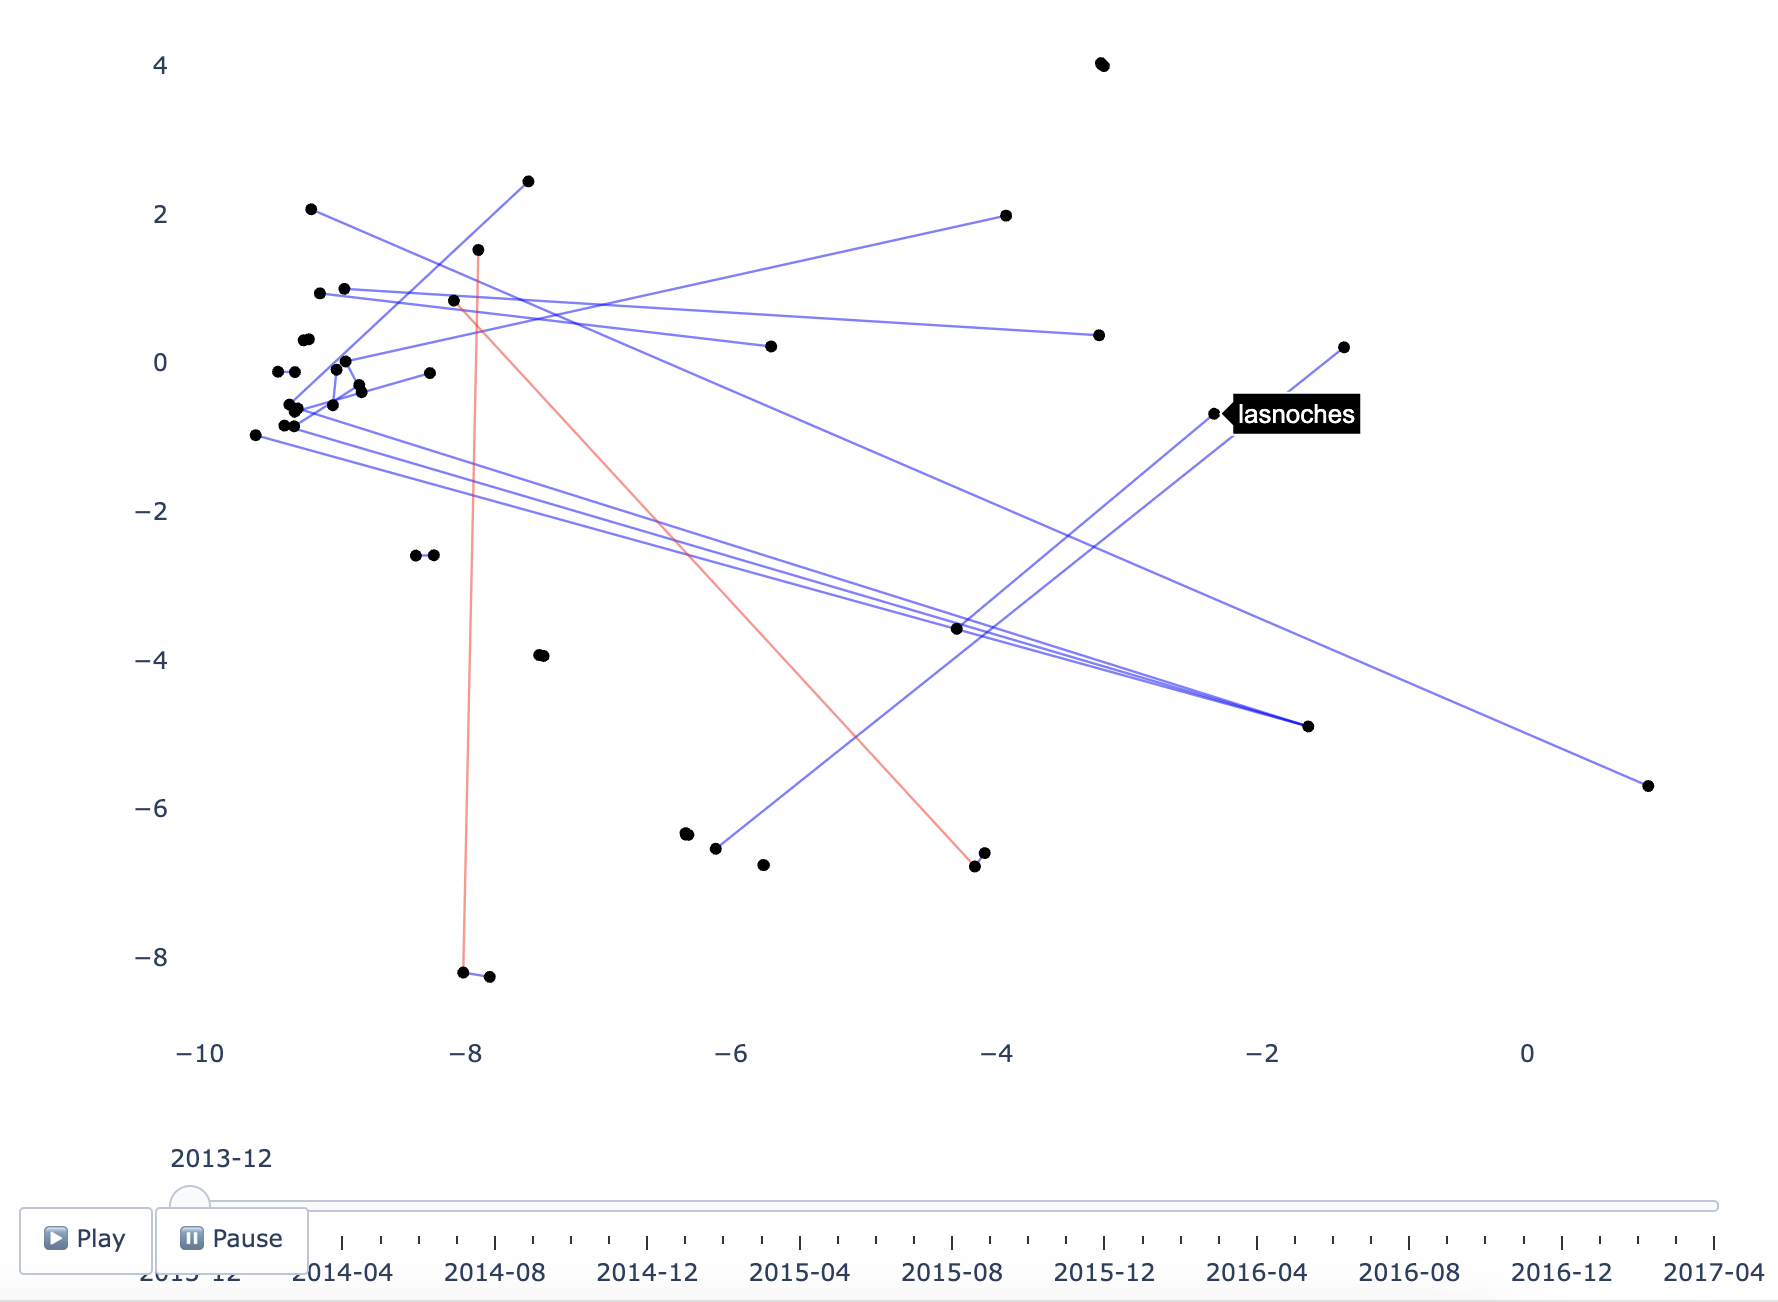

**Screenshot 2:**

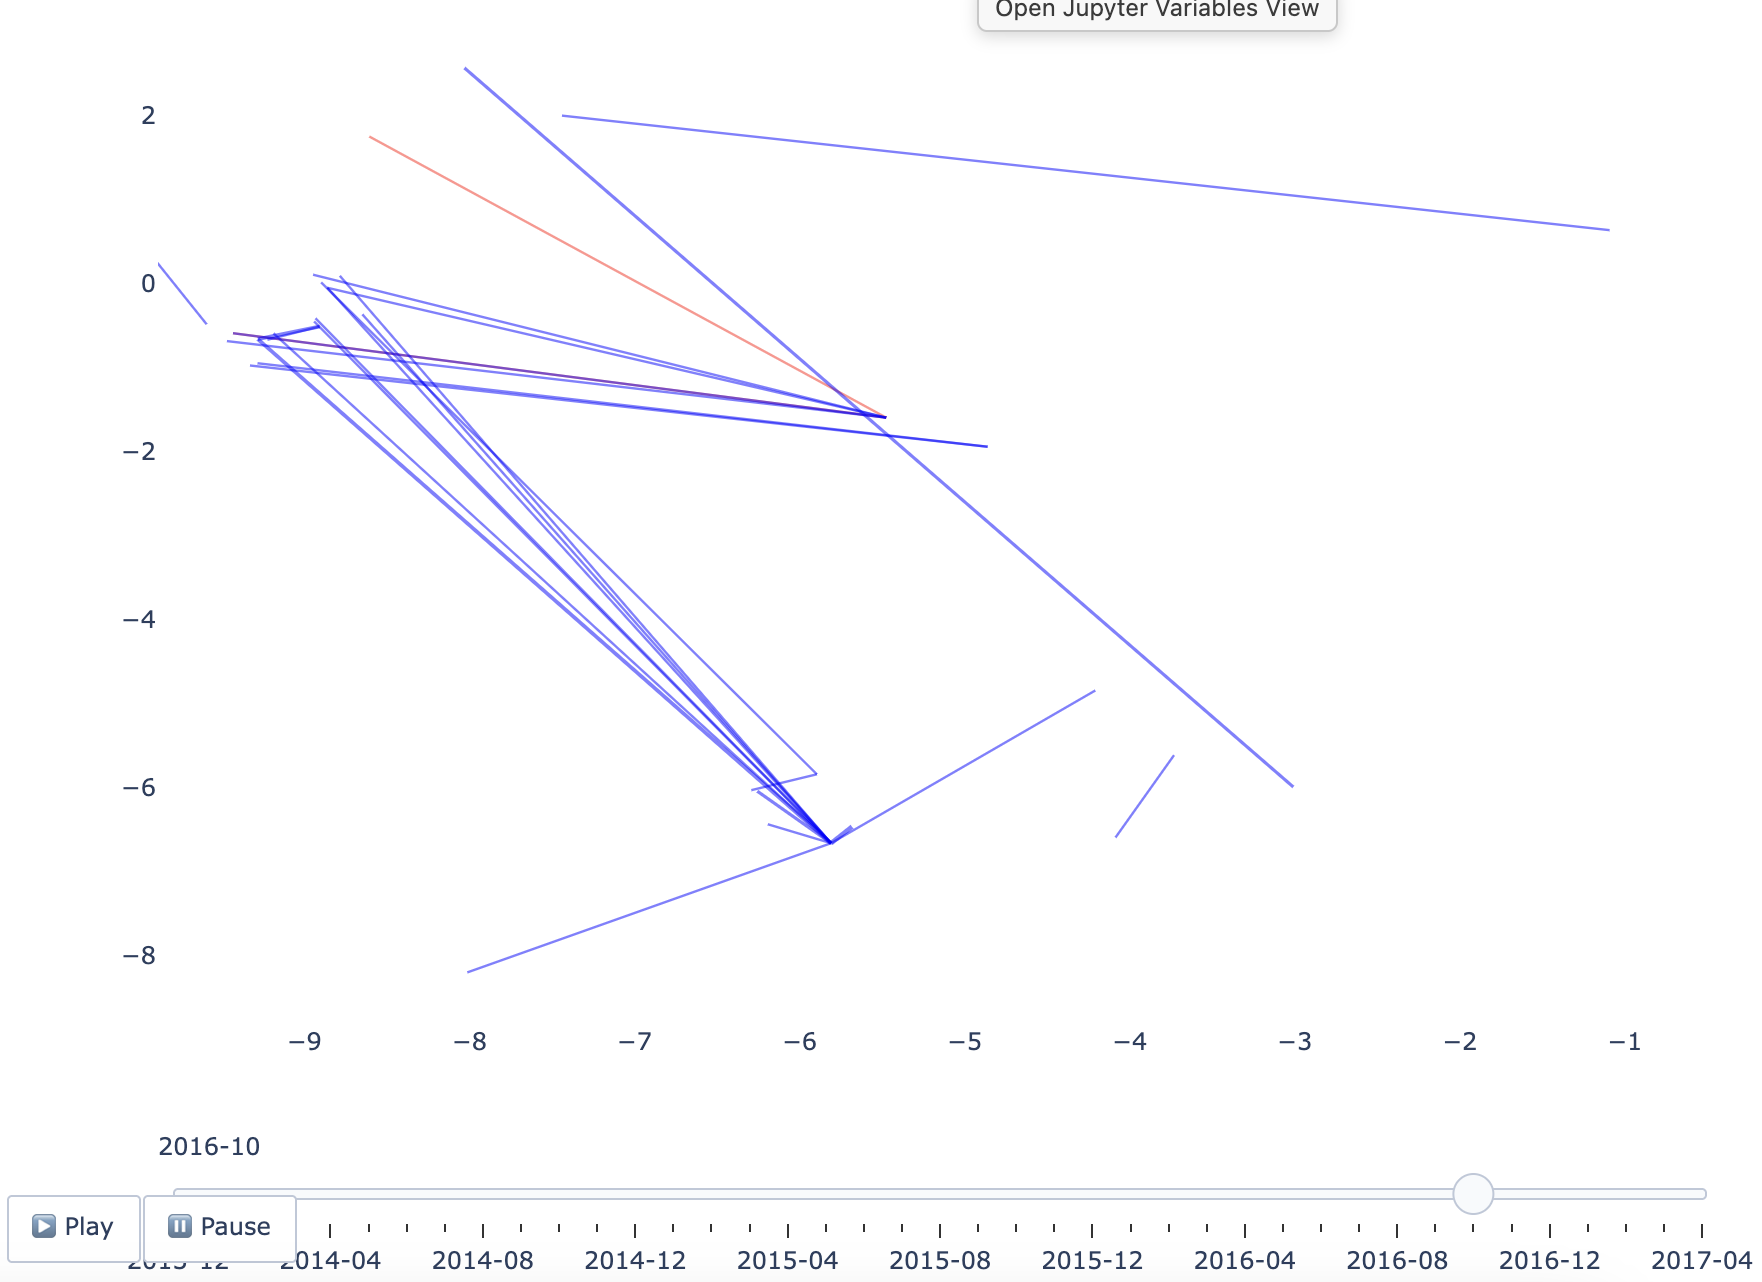

## PART 7 : HIDDEN HOSTILITY

Since our broader goal is to examine whether shared opposition (“the enemy of my enemy”) fosters alliances, it is crucial that our sentiment data accurately reflects genuine hostility. A misclassified link, for instance, a sarcastic or passive-aggressive comment labeled as neutral, could distort our understanding of conflict dynamics and alliance formation.  

Studying hidden hostilities therefore serves as a necessary first step: by identifying and correcting potential mislabelings, we aim to build a cleaner, more reliable foundation for analyzing how cooperation and conflict emerge and evolve between online communities.

The 'augment_hostility_df' function creates a copy of our dataset (df_hostility) and adds two key columns — the cosine similarity between source and target communities and a binary sentiment indicator — to prepare the data for analyzing how community similarity relates to hostility.

In [95]:
df_hostility = augment_hostility_df(df, emb_df)

### 7.1 General Observation 

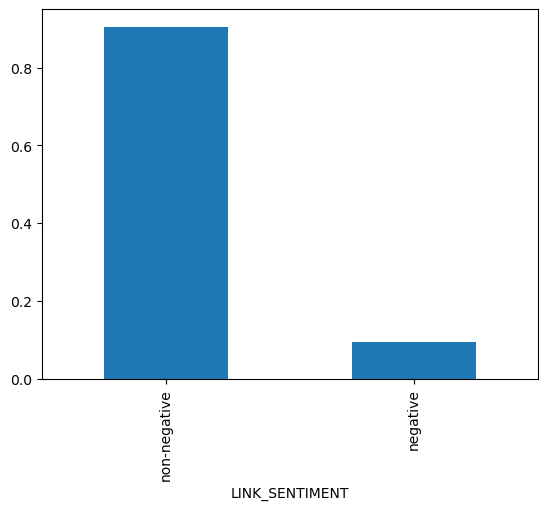

In [96]:
plots.plot_general_analysis(df)

We observe that the share of negatively labeled links is much smaller than that of non-negative ones, suggesting the presence of underlying or hidden hostility that is not immediately visible from the overall distribution.

### 7.2 Time-to-flip (Hidden Hostility)

Even if negative links are rare overall, clusters of rapid sign changes within a pair of communities can signal episodic conflict.  
To capture these dynamics, we looked at all consecutive links between the same pair of communities (in either way) whose sentiment flips (from positive to negative or vice versa) within a chosen time window Δt (e.g., 10h, 24h, 2d, 7d).  

The output is a structured dataset regrouping, for each detected flip:
- the origin link and its follow-up,
- their respective timestamps and sentiments,
- the time difference between them,
- and the direction of the follow-up (same or reversed).

Our goal is to identify all potential candidates for hidden hostility.  

We only looked at future follow-ups to avoid double counting interactions.
If we had searched in both temporal directions (past and future), each pair of opposite-sentiment links would have been detected twice, once from each perspective, artificially inflating the number of observed flips.  

Here, the behavior we seek is a rapid change of sentiment between two consecutive links, a pattern that may indicate that the initial sentiment was misinterpreted or mislabeled, revealing a subtler form of antagonism beneath the surface.

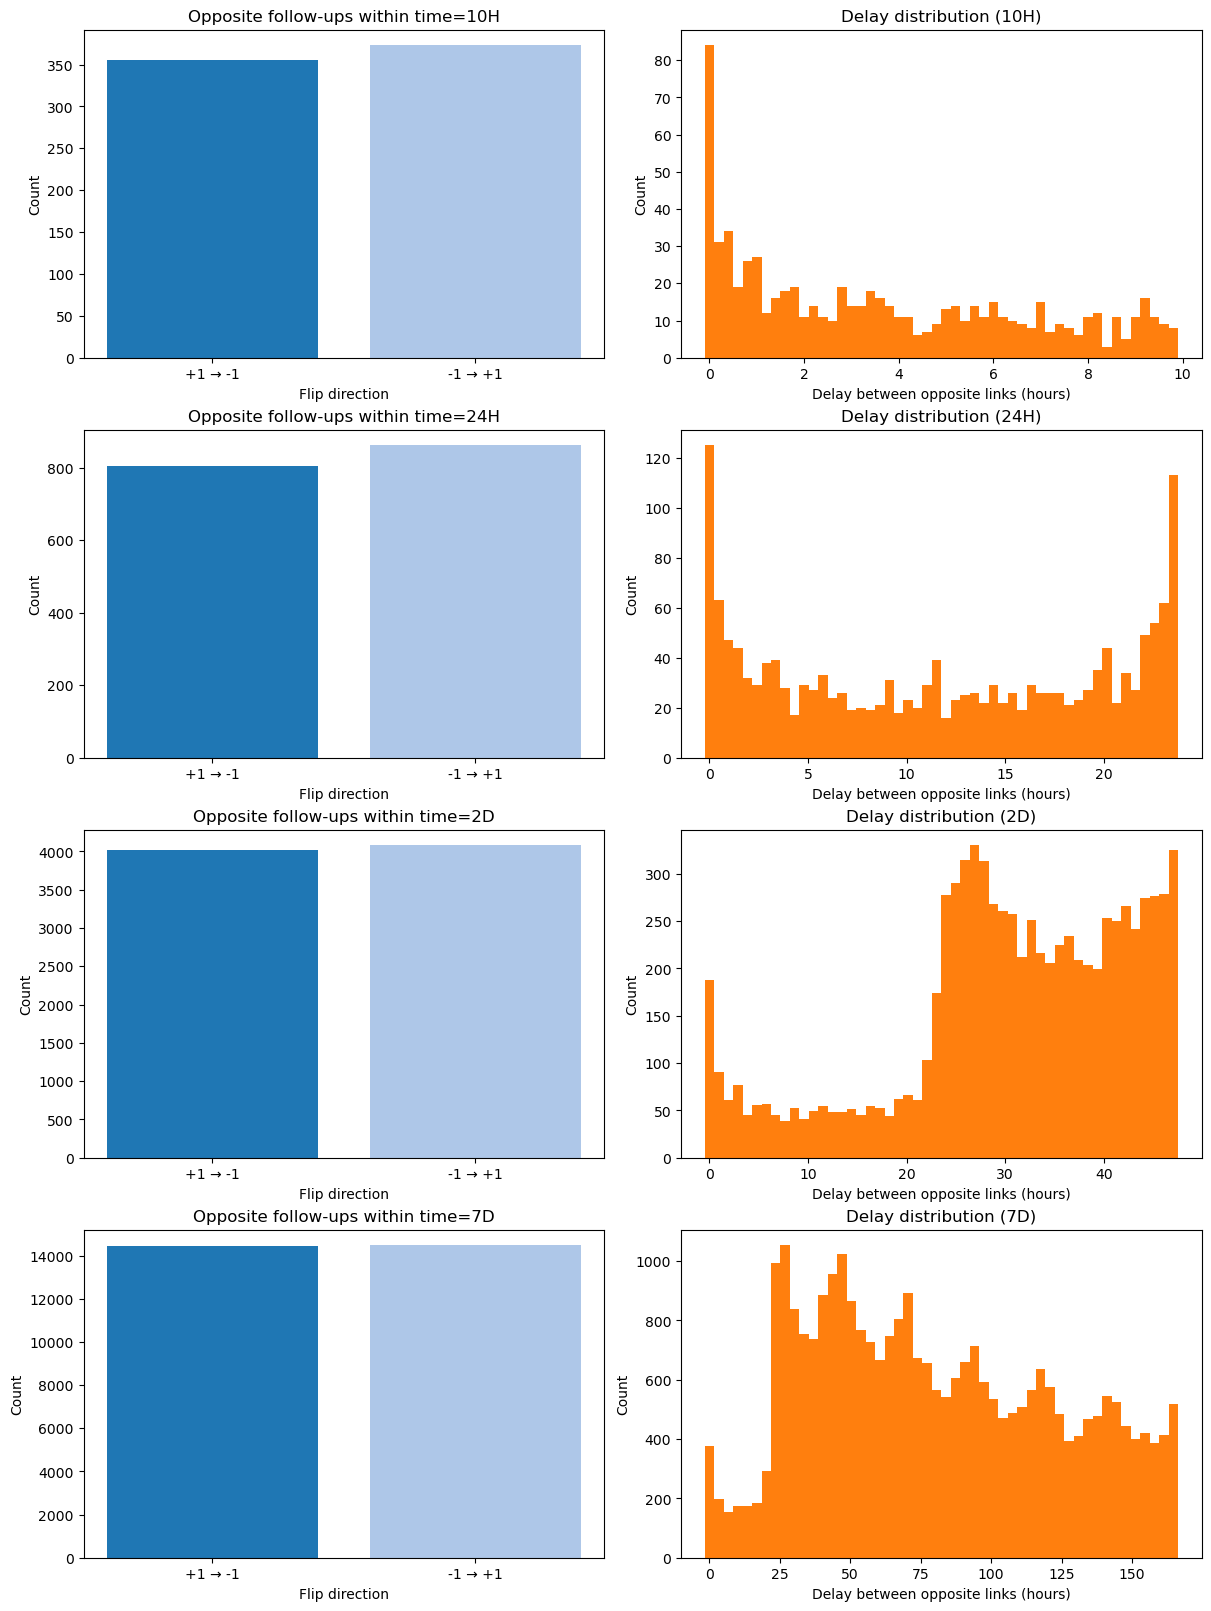

In [97]:
followups_dict = windows_to_followups(df_hostility)

plots.plot_followups_pairs_grid(
    followups_dict,
    hours_map={"10H": 10.0, "24H": 24.0, "2D": 48.0, "7D": 168.0}
)

Across all windows, the number of sentiment flips is balanced between positive→negative and negative→positive, indicating that the model detects both escalation and de-escalation events at similar rates.  
As the time window expands, the number of detected flips increases sharply—from a few hundred at 10 h to over ten thousand at 7 d—because more distant events are included.  

The delay distributions show that most opposite links occur shortly after the first one, with a dense cluster near zero hours. However, when the window becomes very large (2 d or 7 d), the distribution becomes flatter and multi-modal, meaning we start capturing unrelated interactions rather than genuine quick responses.  

Short windows (10 h–24 h) most likely capture real short-term sentiment reversals—the rapid changes we interpret as potential signs of hidden hostility or mislabeling. Longer windows (2 d–7 d) dilute this signal by mixing in delayed or independent posts.

### 7.3 Textual Analysis

In [98]:
df_vader = df_hostility.dropna(subset=["LINK_SENTIMENT","VADER_compound"])
df["LINK_SENTIMENT"] = df["LINK_SENTIMENT"].astype(int)

print("Descriptifs par label:\n", df.groupby("LINK_SENTIMENT")["VADER_compound"].describe(), "\n")

Descriptifs par label:
                    count      mean       std  ...     50%     75%     max
LINK_SENTIMENT                                ...                        
-1               82210.0 -0.315366  0.523547  ... -0.4767  0.0000  0.9999
 1              776278.0  0.151652  0.490875  ...  0.0000  0.5106  1.0000

[2 rows x 8 columns] 



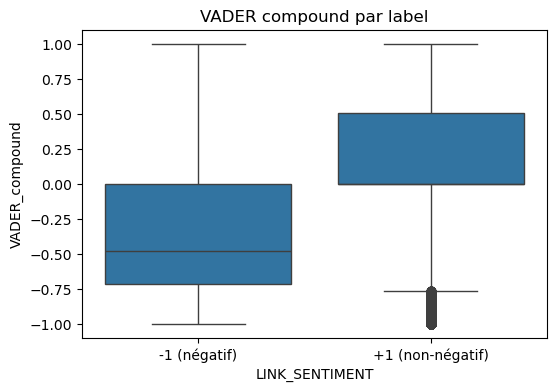

In [99]:
plots.plot_VADER(df_vader)

The VADER sentiment scores align with the expected labeling: negative links have strongly negative compound values, while non-negative links show higher, mostly positive scores. However, the noticeable overlap between the two distributions suggests that some “non-negative” links carry language with negative tones.  

The next steps will aim to provide statistical evidence supporting these observations, confirming whether the detected overlaps and rapid sentiment changes genuinely reflect hidden hostility rather than random variation.

### 7.4 Embedding Analysis

We analyze the cosine similarity distribution of embeddings to examine whether non-negative and negative links tend to occur between communities that are semantically or thematically similar.  

Identifying a significant difference between the two distributions allows us to understand whether semantic proximity influences hostility.  

This measure will also serve later in the project as a control variable, helping us account for similarity effects when studying other behavioral or sentiment patterns—ensuring that observed differences are not simply due to communities being more or less alike in their content.

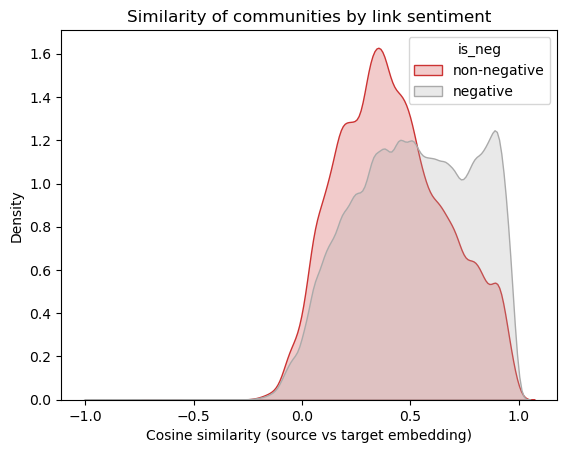

Mann–Whitney p-value: 0.0


In [100]:
plots.plot_embedding_kde_and_test(df_hostility)

The distributions of cosine similarity for non-negative and negative links are clearly distinct.  
Negative links tend to connect communities that are less semantically similar, while non-negative ones mostly occur between closely related communities.  

The Mann–Whitney p-value (≈ 0) confirms this difference is statistically significant, validating that sentiment is influenced by the semantic proximity between communities.

In [101]:
print(df_hostility.cosine_sim.isna().sum())

89653


A significant number of links (≈ 89 k) have a missing cosine similarity value.  
This means that for these pairs, at least one of the communities did not have an available embedding, so their similarity could not be computed.  

As a result, we cannot control for semantic similarity across all links, and our subsequent analyses will only include the subset of pairs where embeddings are available.